<a href="https://colab.research.google.com/github/WVF-1/The-Full-Monty/blob/main/FULPs_V2C_ThompsonSampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs — Version Two C: Thompson Sampling / Bandit

**The third of three Version Two experiments.**

---

## What V2C brings that V2A and V2B do not

V2A and V2B both use the Dirichlet **expected value** as role weights:

```
role_weights = E[Dirichlet(alpha)] = alpha_k / sum(alpha)
```

This is **exploitation only** — the Skepsi always bets on its current best guess.
A role with low alpha never gets to prove itself because it never gets selected.

V2C introduces **exploration** through Thompson Sampling:

```
role_weights = sample from Dirichlet(alpha)
```

Each inference, the Skepsi draws a random role configuration from its posterior
distribution. Roles with high alpha will dominate most draws (exploitation).
Roles with low alpha occasionally win a draw and lead the inference (exploration).
If that exploration succeeds, the role's alpha grows. If it fails, no update.
Over time, genuinely useful roles accumulate evidence. Useless ones don't.
No decay needed. No bounding needed. Exploration and exploitation are automatic.

---

## Three V2C mechanisms

| # | Name | Description |
|---|------|-------------|
| 1 | **Thompson Sampling roles** | FULP 5: sample from Dirichlet at inference time instead of using means |
| 2 | **Complementary PSA recruitment** | PSA expansion prefers Skepsis whose dominant sampled role is underrepresented in the current Symposium |
| 3 | **Exploration tracking** | Each inference logs whether the sampled role differed from the deterministic dominant (exploration event) |

---

## What V2C inherits from V2A and V2B

- **Beta(alpha, beta)** for reputation and cooperation (V2A)
- **Dirichlet(alpha_1...alpha_9)** for role posteriors (V2A)
- **initial_result snapshot** for credit attribution (ARE Enhanced)
- **Geometric mean** for FULP 6 Peer Review (V2A)
- **Evidence-weighted combination** for FULP 7 (V2A)
- **9 x 9 grid**, MAX_PSA_LEVELS = 9
- **Size-invariant confidence** formula

---

## What V2C changes

| Component | V2A | V2B | V2C |
|-----------|-----|-----|-----|
| Role weights | Dirichlet means | Dirichlet means | **Dirichlet sample** |
| FULP 6 | Geometric mean | Directed BP | Geometric mean |
| FULP 7 | Evidence-weighted | Damped BP | Evidence-weighted |
| PSA recruitment | Manhattan shell | Manhattan shell | **Complementary-biased shell** |

V2C is the simplest structural change of the three — one line in activate() — but
it is also the most fundamental, because it changes the epistemology of the system.
V2A and V2B ask: *what do I think is true?* V2C asks: *what should I try next?*


In [140]:
# ── Cell 1: Install ─────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['torch','scipy','scikit-learn','pandas','matplotlib','seaborn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'--quiet'],capture_output=True)
print('Packages ready.')


Packages ready.


In [141]:
# ── Cell 2: Imports and Configuration ───────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
OUT_DIR = '/content' if os.path.exists('/content') else '.'

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H, GRID_W  = 9, 9
MAX_PSA_LEVELS  = 2
SUBSPACE_FRAC   = 0.6

# ── Thresholds (unchanged) ───────────────────────────────────────────────────
CONF_ACCEPT    = 0.60
CONT_ACCEPT    = 0.25
CONF_EMERGENCY = 0.40
CONT_EMERGENCY = 0.45
MAX_CONTRADICTION_PASSES  = 3
EARLY_STOP_CONTRADICTION  = 0.10

# ── FULP 1 (unchanged) ───────────────────────────────────────────────────────
VOID_HIDDEN, EA_TARGET_STD, EA_WEIGHT = 16, 0.3, 0.5
VOID_EPOCHS, VOID_BATCH               = 100, 128
DSC_CALIBRATION_PERCENTILE            = 75

# ── FULP 2 memory (unchanged) ────────────────────────────────────────────────
WORKING_EMA, EPISODIC_EMA = 0.6, 0.95

# ── FULP 3 context (unchanged) ───────────────────────────────────────────────
CONTEXT_ALPHA = 0.10

# ── V2A Bayesian parameters (preserved) ──────────────────────────────────────
BETA_ALPHA_INIT = 1.0
BETA_BETA_INIT  = 1.0
DIRICHLET_INIT = 0.25
ROLE_INCREMENT = 1.0
DECISIVE_FACTOR = 0.7

# ── FULP 5 signal thresholds (unchanged) ─────────────────────────────────────
NOVELTY_ROLE_THRESH     = 0.30
ANOMALY_ROLE_THRESH     = 0.30
UNCERTAINTY_ROLE_THRESH = 0.35
CONSENSUS_CONT_THRESH   = 0.20

ALL_ROLES = ['pattern','memory','trend','novelty','uncertainty',
             'causality','prediction','anomaly','consensus']

# ── V2C: Thompson Sampling parameters ─────────────────────────────────────────
#
# TS_ROLE_SEED: RNG seed for Dirichlet sampling.
# Each Skepsi uses its own seed (derived from cell seed) so samples
# are reproducible but independent across the grid.
TS_ROLE_SEED = 42

# COMPLEMENT_BIAS:
#   Weight given to the complementary-role score when ranking candidates
#   for PSA expansion. 0 = pure Manhattan shell (V2A/B behaviour).
#   1 = sort entirely by complement score within each shell.
#   0.35 = 20% complement bias, 80% proximity (distance) bias.
COMPLEMENT_BIAS = 0.20

# ── Baselines (unchanged) ─────────────────────────────────────────────────────
RF_N_ESTIMATORS = 100
GNN_K, GNN_EPOCHS, GNN_HIDDEN, GNN_LR = 5, 100, 32, 1e-3

# ── Experiment ────────────────────────────────────────────────────────────────
GLOBAL_SEED = 42
TEST_SIZE   = 0.25

# ── Plotting ─────────────────────────────────────────────────────────────────
TIER_COLORS  = {'S':'#4c72b0','M':'#55a868','L':'#c44e52','XL':'#8172b2'}
MODEL_COLORS = {'RF':'#4c72b0','GNN':'#55a868','FULP2C':'#c44e52'}
ROLE_COLORS  = {
    'pattern':'#4c72b0','memory':'#55a868','trend':'#c44e52','novelty':'#8172b2',
    'uncertainty':'#ccb974','causality':'#64b5cd','prediction':'#dd8452',
    'anomaly':'#937860','consensus':'#76b900',
}
plt.rcParams.update({
    'font.family':'monospace','axes.titlesize':10,'axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,
    'axes.grid':True,'grid.alpha':0.3,
})
STATE_INACTIVE   = 'INACTIVE'
STATE_EVALUATING = 'EVALUATING'
STATE_PEER_REVIEW= 'PEER_REVIEW'

print('Configuration loaded.')
print(f'Grid: {GRID_H}x{GRID_W} = {GRID_H*GRID_W} Skepsis  |  MAX_PSA_LEVELS={MAX_PSA_LEVELS}')
print(f'V2C Thompson Sampling parameters:')
print(f'  TS_ROLE_SEED     = {TS_ROLE_SEED}  (per-Skepsi Dirichlet sampling seed)')
print(f'  COMPLEMENT_BIAS  = {COMPLEMENT_BIAS}  (PSA recruitment bias toward complementary roles)')


Configuration loaded.
Grid: 9x9 = 81 Skepsis  |  MAX_PSA_LEVELS=2
V2C Thompson Sampling parameters:
  TS_ROLE_SEED     = 42  (per-Skepsi Dirichlet sampling seed)
  COMPLEMENT_BIAS  = 0.2  (PSA recruitment bias toward complementary roles)


In [142]:
# ── Cell 3: Synthetic Datasets (unchanged) ───────────────────────────────────
TIER_SIZES = {'S':200,'M':400,'L':800,'XL':1600}

def _gen_S(n,rng):
    f1=rng.normal(0,1,n); f2=rng.normal(0,1,n); f3=rng.normal(0,1,n)
    s=1.5*f1-1.2*f2+0.3*f3+rng.normal(0,0.15,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3}),(s>0).astype(int),s

def _gen_M(n,rng):
    X,_,s=_gen_S(n,rng); f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    sm=s+0.8*f4**2-0.5*f4*X['f2'].values+rng.normal(0,0.25,n)
    X['f1']+=rng.normal(0,0.05,n); X['f2']+=rng.normal(0,0.05,n)
    X['f4']=f4; X['f5']=f5
    return X,np.where(sm>0.4,1,np.where(sm<-0.4,0,2)),sm

def _gen_L(n,rng):
    f2=rng.normal(0,1,n); f3=rng.normal(0,1,n); f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    f1=np.zeros(n); f1[0]=rng.normal(0,1)
    for t in range(1,n): f1[t]=0.6*f1[t-1]+0.4*rng.normal(0,1)
    f6=np.roll(f1,1); f6[0]=0.0
    sl=1.5*f1-1.2*f2+0.3*f3+0.8*f4**2-0.5*f4*f2+0.5*f1*f4+0.4*f6+rng.normal(0,0.40,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3,'f4':f4,'f5':f5,'f6':f6}),np.digitize(sl,np.quantile(sl,[.25,.5,.75])),sl

def _gen_XL(n,rng):
    X,_,sl=_gen_L(n,rng)
    xc=rng.uniform(0,10,n); yc=rng.uniform(0,10,n)
    d=np.stack([np.hypot(xc-c[0],yc-c[1]) for c in [[2,2],[8,2],[5,8]]],axis=1)
    sxl=sl+(d.argmin(axis=1)-1.0)*1.2+rng.normal(0,0.30,n)
    y=np.digitize(sxl,np.quantile(sxl,[.2,.4,.6,.8]))
    contra=np.hypot(xc-5,yc-5)<1.5
    if contra.sum()>0: y[contra]=rng.integers(0,5,contra.sum())
    X['x_coord']=xc; X['y_coord']=yc
    X['f7_irr']=rng.normal(0,1,n); X['f8_irr']=rng.uniform(-1,1,n)
    X['contradiction_zone']=contra.astype(int)
    return X,y,sxl

_GEN={'S':_gen_S,'M':_gen_M,'L':_gen_L,'XL':_gen_XL}

def generate_dataset(tier,n=None,seed=42):
    rng=np.random.default_rng(seed); n=n or TIER_SIZES[tier]
    X,y,_=_GEN[tier](n,rng)
    return X.reset_index(drop=True),np.asarray(y),int(np.unique(y).size)

for t in ['S','M','L','XL']:
    X,y,k=generate_dataset(t)
    print(f'{t}: rows={len(X)} features={X.shape[1]} classes={k}')


S: rows=200 features=3 classes=2
M: rows=400 features=5 classes=3
L: rows=800 features=6 classes=4
XL: rows=1600 features=11 classes=5


In [143]:
# ── Cell 4: FULP 1 — VoidStabilizer (unchanged) ─────────────────────────────

class InnerDepthField:
    def __init__(self,dim): self.dim=dim
    def _corr(self,rho):
        idx=np.arange(self.dim)
        return rho**np.abs(idx[:,None]-idx[None,:])+np.eye(self.dim)*1e-6
    def sample(self,n,rng):
        X=np.zeros((n,self.dim))
        for i in range(n):
            mu=rng.normal(0,0.02); sig=rng.uniform(0.05,0.30); rho=rng.uniform(-0.2,0.2)
            try:
                L=cholesky(self._corr(rho),lower=True); X[i]=mu+sig*(L@rng.normal(0,1,self.dim))
            except: X[i]=rng.normal(mu,sig,self.dim)
        return X.astype(np.float32)

class VoidStabilizer(nn.Module):
    def __init__(self,dim,hidden=VOID_HIDDEN,ea_target_std=EA_TARGET_STD,ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std=ea_target_std; self.ea_weight=ea_weight
        self.encoder=nn.Sequential(nn.Linear(dim,hidden),nn.Tanh()); self.decoder=nn.Linear(hidden,dim)
    def forward(self,x): z=self.encoder(x); return self.decoder(z),z
    def dsc(self,x): x_hat,_=self.forward(x); return torch.mean((x-x_hat)**2,dim=1)
    def training_loss(self,x):
        x_hat,z=self.forward(x)
        r=nn.functional.mse_loss(x_hat,x); e=(z.std()-self.ea_target_std)**2
        return r+self.ea_weight*e,r.item(),e.item()

def train_void_stabilizer(dim,seed=GLOBAL_SEED,n_epochs=VOID_EPOCHS,batch_size=VOID_BATCH):
    rng=np.random.default_rng(seed); idf=InnerDepthField(dim); model=VoidStabilizer(dim)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    for _ in range(n_epochs):
        x=torch.FloatTensor(idf.sample(batch_size,rng))
        loss,_,_=model.training_loss(x); opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); return model,idf

def calibrate_dsc_threshold(void_model,idf,rng,X_scaled,percentile=DSC_CALIBRATION_PERCENTILE):
    with torch.no_grad():
        err=void_model.dsc(torch.FloatTensor(X_scaled.astype(np.float32))).numpy()
    return float(np.percentile(err,percentile))

print('FULP 1 — VoidStabilizer defined (unchanged).')


FULP 1 — VoidStabilizer defined (unchanged).


In [144]:
# ── Cell 5: Bayesian Utilities and Geometric Mean (preserved from V2A) ────────

class BetaEstimator:
    def __init__(self,alpha=BETA_ALPHA_INIT,beta=BETA_BETA_INIT):
        self.alpha=float(alpha); self.beta=float(beta)
    @property
    def mean(self): return self.alpha/(self.alpha+self.beta)
    @property
    def variance(self):
        a,b=self.alpha,self.beta; return a*b/((a+b)**2*(a+b+1))
    @property
    def concentration(self): return self.alpha+self.beta-BETA_ALPHA_INIT-BETA_BETA_INIT
    def update(self,success):
        if success: self.alpha+=1.0
        else:       self.beta +=1.0
    def __repr__(self):
        return f'Beta(a={self.alpha:.1f},b={self.beta:.1f}) mean={self.mean:.3f}'


class DirichletEstimator:
    """
    Dirichlet posterior over role space.

    V2A/V2B use .means (expected value) as role weights — deterministic exploitation.
    V2C uses .sample() (Thompson Sampling) — stochastic exploration + exploitation.
    The alpha parameters are updated identically across all three versions.
    """
    def __init__(self,categories=ALL_ROLES,alpha_init=DIRICHLET_INIT):
        self.alpha={c:float(alpha_init) for c in categories}

    @property
    def means(self):
        """Deterministic posterior mean. Used by V2A and V2B."""
        total=sum(self.alpha.values()); return {c:self.alpha[c]/total for c in self.alpha}

    def sample(self,rng):
        """
        Thompson Sampling: draw one sample from Dirichlet(alpha).
        Returns a dict of role->weight for this inference only.
        The sampled weights are stochastic but distributed according to
        current posterior uncertainty. High-alpha roles dominate most draws;
        low-alpha roles occasionally win and get to prove themselves.
        """
        alpha_vec=np.array([self.alpha[r] for r in ALL_ROLES])
        sampled=rng.dirichlet(alpha_vec)
        return {r:float(sampled[i]) for i,r in enumerate(ALL_ROLES)}

    @property
    def concentration(self): return sum(self.alpha.values())-len(self.alpha)*DIRICHLET_INIT

    @property
    def dominant(self): return max(self.alpha,key=self.alpha.get)

    @property
    def entropy(self):
        p=np.array(list(self.means.values())); p=np.clip(p,1e-10,1.0)
        return float(-np.sum(p*np.log(p))/np.log(len(p)))

    def update(self,role,increment=1.0):
        if role in self.alpha: self.alpha[role]+=float(increment)

    def __repr__(self):
        return f'Dirichlet(dominant={self.dominant}, conc={self.concentration:.1f}, H={self.entropy:.3f})'


def log_combine_probs(probs_list,weights):
    """Reputation-weighted geometric mean. Preserved from V2A."""
    weights=np.array(weights,dtype=float); weights=np.clip(weights,1e-9,None)
    log_c=np.zeros(len(probs_list[0]))
    for p,w in zip(probs_list,weights):
        log_c+=w*np.log(np.clip(np.asarray(p),1e-10,1.0))
    log_c-=log_c.max(); c=np.exp(log_c); return c/(c.sum()+1e-10)


print('Bayesian utilities defined.')
print('  BetaEstimator:     Beta posterior for reputation and cooperation')
print('  DirichletEstimator: .means = deterministic (V2A/B)')
print('                      .sample(rng) = Thompson Sampling (V2C)')
print('  log_combine_probs: geometric mean for FULP 6/7')


Bayesian utilities defined.
  BetaEstimator:     Beta posterior for reputation and cooperation
  DirichletEstimator: .means = deterministic (V2A/B)
                      .sample(rng) = Thompson Sampling (V2C)
  log_combine_probs: geometric mean for FULP 6/7


In [145]:
# ── Cell 6: MicrocellBank (Version 2D) ───────────────────────────────────────

def _full_proba(clf, x_row, n_classes):
    p = clf.predict_proba(x_row.reshape(1,-1))[0]
    out = np.zeros(n_classes)
    for c, pc in zip(clf.classes_, p):
        out[int(c)] = pc
    s = out.sum()
    return out/s if s > 0 else np.full(n_classes,1.0/n_classes)


class MicrocellBank:

    def __init__(self, feature_idx, causal_idx,
                 void_model, dsc_threshold, seed):

        self.feature_idx = feature_idx
        self.causal_idx = causal_idx

        self.void_model = void_model
        self.dsc_threshold = dsc_threshold
        self.seed = seed

        self.n_classes = None
        self.activated = False

        self.working_memory = None
        self.episodic_memory = None

        self._last_novelty = 0.0
        self._last_anomaly = 0.0


    def fit(self, X_train, y_train, n_classes):

        self.n_classes = n_classes

        Xs = X_train[:, self.feature_idx]
        Xc = X_train[:, self.causal_idx]

        # Stronger models
        self.pattern_clf = DecisionTreeClassifier(
            max_depth=6,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.prediction_clf = RandomForestClassifier(
            n_estimators=30,
            max_depth=8,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.trend_clf = LogisticRegression(
            max_iter=1000,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.causality_clf = DecisionTreeClassifier(
            max_depth=5,
            random_state=self.seed
        ).fit(Xc, y_train)

        self._anomaly_mean = Xs.mean(axis=0)

        return self


    def reset_working_memory(self):
        self.working_memory = None


    def consolidate_memory(self, final_probs):

        if self.episodic_memory is None:
            self.episodic_memory = final_probs.copy()

        else:
            # Faster adaptation than before
            self.episodic_memory = (
                0.85*self.episodic_memory
                + 0.15*final_probs
            )


    def evaluate(self, x_full, role_weights=None):

        self.activated = True

        n = self.n_classes

        xs = x_full[self.feature_idx]
        xc = x_full[self.causal_idx]

        pv  = _full_proba(self.pattern_clf, xs, n)
        prv = _full_proba(self.prediction_clf, xs, n)
        tv  = _full_proba(self.trend_clf, xs, n)
        cv  = _full_proba(self.causality_clf, xc, n)

        # ---- novelty ----
        with torch.no_grad():
            dsc = float(
                self.void_model.dsc(
                    torch.FloatTensor(x_full).unsqueeze(0)
                )
            )

        nov = float(
            np.clip(
                dsc/(self.dsc_threshold+1e-8)-1.0,
                0,
                1
            )
        )

        # ---- anomaly ----
        az = float(np.mean(np.abs(xs-self._anomaly_mean)))

        anom = float(
            np.clip(
                (az-1.0)/2.0,
                0,
                1
            )
        )

        self._last_novelty = nov
        self._last_anomaly = anom

        # ---- raw average ----
        raw_avg = np.mean(
            [pv, prv, tv, cv],
            axis=0
        )

        # ---- working memory ----
        if self.working_memory is None:
            self.working_memory = raw_avg.copy()

        else:
            self.working_memory = (
                0.4*self.working_memory
                + 0.6*raw_avg
            )

        # ---- episodic memory ----
        if self.episodic_memory is not None:

            mv = (
                0.7*self.working_memory
                + 0.3*self.episodic_memory
            )

        else:
            mv = self.working_memory.copy()

        # =====================================================
        # Consensus
        # =====================================================

        vectors = [pv, prv, tv, cv, mv]

        # only activate novelty when significant
        if nov > 0.20:

            novelty_vec = np.full(n,1.0/n)

            vectors.append(novelty_vec)

        # only activate anomaly when significant
        if anom > 0.20:

            anomaly_vec = np.full(n,1.0/n)

            vectors.append(anomaly_vec)

        all_v = np.stack(vectors)

        cons = np.mean(all_v, axis=0)

        # =====================================================
        # Uncertainty
        # =====================================================

        p = np.clip(cons,1e-9,1.0)

        H = -np.sum(
            p*np.log(p)
        ) / np.log(n)

        cc = int(np.argmax(cons))

        # =====================================================
        # Contradiction
        # probability disagreement
        # =====================================================

        disagreement = np.mean([
            np.mean(np.abs(pv-prv)),
            np.mean(np.abs(pv-tv)),
            np.mean(np.abs(pv-cv)),
            np.mean(np.abs(pv-mv))
        ])

        contradiction = float(
            np.clip(
                disagreement
                + 0.30*anom
                + 0.30*nov,
                0,
                1
            )
        )

        # =====================================================
        # Confidence
        # =====================================================

        confidence = float(
            np.clip(
                np.max(cons)
                * (1-0.4*H)
                * (1-0.3*nov)
                * (1-0.2*anom),
                0,
                1
            )
        )

        return {
            'probs': cons,
            'prediction': cc,
            'confidence': confidence,
            'contradiction': contradiction,
            'novelty': nov,
            'anomaly': anom,
            'uncertainty': H,
            'memory_vec': mv,
            'n_microcells_run': len(vectors),

            'microcell_predictions':{
                'pattern': int(np.argmax(pv)),
                'prediction': int(np.argmax(prv)),
                'trend': int(np.argmax(tv)),
                'causality': int(np.argmax(cv)),
                'memory': int(np.argmax(mv))
            }
        }


print("MicrocellBank V2D defined.")

MicrocellBank V2D defined.


In [146]:
# ── Cell 7: Skepsi V2C — Thompson Sampling ───────────────────────────────────
#
# The only structural difference from V2A Skepsi is in activate():
#
#   V2A: role_weights = self.role_dirichlet.means      (deterministic)
#   V2C: role_weights = self.role_dirichlet.sample(rng) (stochastic)
#
# Everything else — reputation, cooperation, context, learning, memory —
# is identical to V2A.
#
# Two new instance variables support V2C analysis:
#   self.ts_rng         : per-Skepsi RNG for Dirichlet sampling
#   self.sampled_role_history : list of sampled dominant roles per inference
#
# sampled_role_history enables the exploration rate visualisation: we can
# count how often the sampled dominant role differed from the Dirichlet mean
# dominant role (pure exploration events).

class Skepsi:
    """V2C Skepsi: Thompson Sampling for role selection at inference time."""

    def __init__(self,row,col,feature_idx,causal_idx,void_model,dsc_threshold,seed):
        self.row=row; self.col=col
        self.bank=MicrocellBank(feature_idx,causal_idx,void_model,dsc_threshold,seed)
        self.state=STATE_INACTIVE; self.result=None; self.initial_result=None

        # ── V2A Bayesian state (preserved) ──────────────────────────────
        self.rep_beta       = BetaEstimator()
        self.role_dirichlet = DirichletEstimator()
        self.coop_beta      = BetaEstimator()
        self.context={'samples_seen':0,'avg_confidence':0.0,
                      'avg_contradiction':0.0,'avg_novelty':0.0}

        # ── V2C: per-Skepsi Thompson Sampling RNG ───────────────────────
        # Each Skepsi has its own RNG derived from its cell seed.
        # This makes samples reproducible and independent across the grid.
        self.ts_rng = np.random.default_rng(seed + TS_ROLE_SEED)

        # ── V2C: history of sampled dominant roles ───────────────────────
        # Records which role won the Dirichlet draw each inference.
        # Enables exploration rate calculation.
        self.sampled_role_history = []
        self.sampled_weights_last = None   # most recent sampled weights

    def fit(self,X_train,y_train,n_classes):
        self.bank.fit(X_train,y_train,n_classes); return self

    # ── Properties (identical to V2A) ─────────────────────────────────────
    @property
    def reputation(self): return self.rep_beta.mean
    @property
    def cooperation(self): return self.coop_beta.mean
    @property
    def role_vector(self): return self.role_dirichlet.means     # deterministic mean
    @property
    def dominant_role(self): return self.role_dirichlet.dominant

    @property
    def exploration_rate(self):
        """
        Fraction of inferences where the sampled dominant role differed from
        the deterministic dominant (Dirichlet mean argmax).
        0.0 = always exploiting the known best role.
        1.0 = always exploring different roles (would indicate a flat prior).
        """
        if not self.sampled_role_history: return 0.0
        det_dom = self.dominant_role
        return float(sum(r != det_dom for r in self.sampled_role_history) /
                     len(self.sampled_role_history))

    @property
    def sampled_dominant_counts(self):
        """Distribution of which role was sampled as dominant across inferences."""
        return Counter(self.sampled_role_history)

    @property
    def stubbornness(self):
        """Emergent from reputation x confidence (same as V2A)."""
        if self.result is not None:
            return float(np.clip(self.rep_beta.mean*self.result['confidence'],0.05,0.95))
        return float(np.clip(self.rep_beta.mean,0.05,0.95))

    # ── Per-sample lifecycle ──────────────────────────────────────────────
    def reset(self):
        self.state=STATE_INACTIVE; self.result=None; self.initial_result=None
        self.bank.reset_working_memory()

    def activate(self,x_scaled,state=STATE_EVALUATING):
        """
        V2C: Thompson Sampling role selection.

        Instead of using Dirichlet means as deterministic weights,
        we draw a sample from the current Dirichlet posterior.
        The sampled weights reflect our current uncertainty about which role
        is truly best — high-alpha roles win most draws, but low-alpha roles
        occasionally win and have a chance to prove themselves.

        After the inference completes:
        - If the sampled role led to a correct prediction, its alpha grows.
        - If not, no alpha update (Bayesian principle: no negative evidence).
        - Over time, genuinely useful roles accumulate alpha faster than useless ones.
        """
        self.state=state

        # ── THE V2C CHANGE: sample from Dirichlet instead of using mean ──
        sampled_weights = self.role_dirichlet.sample(self.ts_rng)
        self.sampled_weights_last = sampled_weights

        # Track which role dominated this particular draw
        sampled_dom = max(sampled_weights, key=sampled_weights.get)
        self.sampled_role_history.append(sampled_dom)

        # Run microcells with sampled role weights
        raw = self.bank.evaluate(x_scaled, role_weights=sampled_weights)

        # Save pre-FULP-6/7 snapshot for credit attribution (preserved fix)
        self.initial_result = {k:raw[k].copy() if isinstance(raw[k],np.ndarray) else raw[k]
                               for k in raw}
        self.result = raw
        return self.result

    # ── V2A FULP updates (preserved verbatim) ─────────────────────────────
    def consolidate_memory(self):
        if self.result is not None: self.bank.consolidate_memory(self.result['probs'])

    def update_context(self,result):
        n=self.context['samples_seen']
        if n==0:
            self.context.update(avg_confidence=result['confidence'],
                                avg_contradiction=result['contradiction'],
                                avg_novelty=result.get('novelty',0.0))
        else:
            a=CONTEXT_ALPHA
            self.context['avg_confidence']   =(1-a)*self.context['avg_confidence']   +a*result['confidence']
            self.context['avg_contradiction']=(1-a)*self.context['avg_contradiction']+a*result['contradiction']
            self.context['avg_novelty']      =(1-a)*self.context['avg_novelty']      +a*result.get('novelty',0.0)
        self.context['samples_seen']+=1

    def update_reputation(self,was_correct):
        self.rep_beta.update(was_correct)

    def update_role_vector(self, result, was_correct, agreed):
        """
        V2C role learning.

        Only the sampled dominant role receives the main reward.
        This allows Thompson Sampling to discover which roles
        genuinely perform best.

        Auxiliary roles (novelty, anomaly, uncertainty, consensus)
        still receive smaller context rewards.
        """

        if not was_correct:
            return

        # -----------------------------
        # Reward the sampled dominant role
        # -----------------------------
        sampled_role = self.sampled_role_history[-1]

        self.role_dirichlet.update(
            sampled_role,
            ROLE_INCREMENT
        )

        # -----------------------------
        # Context-dependent auxiliary roles
        # -----------------------------
        novelty = result.get('novelty',0.0)
        anomaly = result.get('anomaly',0.0)
        uncertainty = result.get('uncertainty',1.0)
        contradiction = result.get('contradiction',1.0)

        if novelty > NOVELTY_ROLE_THRESH:
            self.role_dirichlet.update('novelty',0.5)

        if anomaly > ANOMALY_ROLE_THRESH:
            self.role_dirichlet.update('anomaly',0.5)

        if uncertainty < UNCERTAINTY_ROLE_THRESH:
            self.role_dirichlet.update('uncertainty',0.5)

        if contradiction < CONSENSUS_CONT_THRESH and agreed:
            self.role_dirichlet.update('consensus',0.5)

    def update_cooperation(self,was_in_peer_review,prediction_correct):
        if was_in_peer_review: self.coop_beta.update(prediction_correct)

    def compose_message(self):
        if self.result is None: return None
        return {'probs':self.result['probs'].copy(),'confidence':self.result['confidence'],
                'contradiction':self.result['contradiction'],'memory_vec':self.result['memory_vec'].copy(),
                'reputation':self.reputation,'cooperation':self.cooperation}

    def receive_message(self,msg):
        if msg is not None: self.mailbox.append(msg)

    def apply_messages(self,x_scaled):
        if not hasattr(self,'mailbox') or not self.mailbox or self.result is None:
            return self.result
        probs_list=[self.result['probs']]
        weights   =[self.reputation*self.result['confidence']]
        for msg in self.mailbox:
            probs_list.append(msg['probs'])
            weights.append(msg.get('reputation',0.5)*msg.get('confidence',0.5))
        combined=log_combine_probs(probs_list,weights)
        self.result['probs']     =combined
        self.result['prediction']=int(np.argmax(combined))
        self.result['confidence']=float(np.max(combined))
        return self.result

    @property
    def is_accepted(self):
        if self.result is None: return False
        return self.result['confidence']>=CONF_ACCEPT and self.result['contradiction']<=CONT_ACCEPT

    def __repr__(self):
        er=self.exploration_rate
        return (f'Skepsi({self.row},{self.col}) rep={self.reputation:.2f} '
                f'coop={self.cooperation:.2f} dominant={self.dominant_role} '
                f'explore={er:.2f} state={self.state}')

print('Skepsi V2C defined.')
print('  V2C change: activate() uses Dirichlet.sample() instead of .means')
print('  exploration_rate tracks how often sampled role != deterministic dominant')
print('  All V2A Bayesian updates (rep, role, coop) preserved identically')


Skepsi V2C defined.
  V2C change: activate() uses Dirichlet.sample() instead of .means
  exploration_rate tracks how often sampled role != deterministic dominant
  All V2A Bayesian updates (rep, role, coop) preserved identically


In [147]:
# ── Cell 8: Encephalon V2C — Complementary PSA Recruitment ──────────────────
#
# V2A and V2B activate PSA cells in strict Manhattan shell order.
# V2C modifies this: within each shell, candidate Skepsis are scored by how
# complementary their dominant sampled role is to the current Symposium.
#
# Complementary score for candidate i:
#   complement_score = 1 / (1 + count_of_dominant_role_in_symposium)
#   Role already present 3 times → score = 0.25
#   Role not yet present      → score = 1.00
#
# Recruitment order within shell:
#   recruitment_score = (1 - COMPLEMENT_BIAS) * proximity_score
#                     + COMPLEMENT_BIAS * complement_score
#   where proximity_score = 1.0 for all cells in the same shell (equal distance)
#
# All cells in the shell are still activated (PSA never skips cells).
# The order of activation within a shell determines which Skepsis contribute
# their opinions first in the Peer Review round.
#
# FULP 6: geometric mean (V2A, not BP) — V2C's novelty is in role selection
# FULP 7: evidence-weighted combination (V2A)

def _vn_shell(row,col,level,H,W):
    cells=[]
    if level==0: return [(row,col)]
    for dr in range(-level,level+1):
        dc_abs=level-abs(dr)
        for dc in ([dc_abs,-dc_abs] if dc_abs!=0 else [0]):
            r,c=row+dr,col+dc
            if 0<=r<H and 0<=c<W: cells.append((r,c))
    return cells

def _vn_up_to(row,col,level,H,W):
    cells=set()
    for lv in range(level+1): cells.update(_vn_shell(row,col,lv,H,W))
    return sorted(cells)


class Encephalon:
    """V2C Encephalon: complementary PSA recruitment + Thompson Sampling Skepsis."""

    def __init__(self,grid_h=GRID_H,grid_w=GRID_W,subspace_frac=SUBSPACE_FRAC,
                 void_seed=GLOBAL_SEED,seed=GLOBAL_SEED):
        self.grid_h=grid_h; self.grid_w=grid_w
        self.center=(grid_h//2,grid_w//2)
        self.subspace_frac=subspace_frac; self.seed=seed; self.void_seed=void_seed
        self.rng=np.random.default_rng(seed); self.scaler=StandardScaler()
        self.void_model=None; self.idf=None; self.dsc_threshold=None
        self.n_classes=None; self.n_features=None; self.void_dim=None
        self.grid=None; self._plato=None

    @property
    def plato(self): return self._plato

    def _build_grid(self):
        n=self.n_features; n_sub=max(1,int(n*self.subspace_frac))
        causal=[0,1] if n>=2 else [0]; grid=[]
        for r in range(self.grid_h):
            row=[]
            for c in range(self.grid_w):
                sub=sorted(set(self.rng.choice(n,n_sub,replace=False).tolist())|set(causal))
                seed=int(self.rng.integers(0,1_000_000))
                sk=Skepsi(r,c,sub,causal,self.void_model,self.dsc_threshold,seed)
                sk.mailbox=[]   # initialise mailbox here for FULP 6
                row.append(sk)
            grid.append(row)
        cr,cc=self.center; self._plato=grid[cr][cc]
        return grid

    def fit(self,X_df,y,n_classes,verbose=True):
        X_raw=X_df.values.astype(np.float32)
        self.n_features=X_raw.shape[1]; self.n_classes=n_classes; self.void_dim=self.n_features
        if verbose: print('  [Enc] Training VoidStabilizer (FULP 1)...')
        self.void_model,self.idf=train_void_stabilizer(self.void_dim,seed=self.void_seed)
        rng_cal=np.random.default_rng(self.void_seed)
        X_scaled=self.scaler.fit_transform(X_raw).astype(np.float32)
        self.dsc_threshold=calibrate_dsc_threshold(self.void_model,self.idf,rng_cal,X_scaled)
        if verbose: print(f'  [Enc] DSC threshold (p{DSC_CALIBRATION_PERCENTILE}): {self.dsc_threshold:.4f}')
        self.grid=self._build_grid()
        if verbose: print(f'  [Enc] Fitting {self.grid_h*self.grid_w} Skepsis...')
        for r in range(self.grid_h):
            for c in range(self.grid_w): self.grid[r][c].fit(X_scaled,y,n_classes)
        if verbose: print(f'  [Enc] Plato: {self._plato}')
        if verbose: print('  [Enc] Encephalon V2C ready.')
        return self

    def _cell(self,r,c): return self.grid[r][c]

    def _complement_score(self,r,c,active_set):
        """
        Score candidate (r,c) for complementary recruitment.
        Returns 1/(1 + count) where count = how many active Skepsis already
        have the same dominant sampled role as candidate (r,c).
        """
        sk=self._cell(r,c)
        candidate_dom=sk.dominant_role
        count=sum(1 for (ar,ac) in active_set
                  if self._cell(ar,ac).dominant_role==candidate_dom)
        return 1.0/(1.0+count)

    def _sort_candidates_by_complement(self,new_cells,active_set):
        """
        Sort new_cells for activation order using complementary recruitment.
        All cells will still be activated; the order influences which opinions
        are heard first in the Peer Review round.
        """
        if not active_set:
            return new_cells   # first expansion: no complement scores yet
        scored=[]
        for (r,c) in new_cells:
            cs=self._complement_score(r,c,active_set)
            # blend complement score with uniform (equal proximity within shell)
            rs=COMPLEMENT_BIAS*cs + (1-COMPLEMENT_BIAS)*1.0
            scored.append((rs,r,c))
        scored.sort(key=lambda x:-x[0])
        return [(r,c) for _,r,c in scored]

    # ── FULP 6: Geometric mean Peer Review (V2A) ──────────────────────────
    def peer_review_pass(self,active_set,x_sc):
        for (r,c) in active_set: self._cell(r,c).mailbox=[]
        for (r,c) in active_set:
            msg=self._cell(r,c).compose_message()
            for (nr,nc) in _vn_shell(r,c,1,self.grid_h,self.grid_w):
                if (nr,nc) in active_set: self._cell(nr,nc).receive_message(msg)
        for (r,c) in active_set: self._cell(r,c).apply_messages(x_sc)

    # ── FULP 7: Evidence-weighted contradiction resolution (V2A) ──────────
    def resolve_contradictions(self,active_set):
        passes_used=0
        for _ in range(MAX_CONTRADICTION_PASSES):
            passes_used+=1
            active_results=[(r,c,self._cell(r,c).result)
                            for (r,c) in active_set if self._cell(r,c).result is not None]
            if not active_results: break
            eff_w=np.array([res['confidence']*self._cell(r,c).reputation
                            for r,c,res in active_results])
            eff_w=eff_w/(eff_w.sum()+1e-9)
            combined=log_combine_probs([res['probs'] for _,_,res in active_results],eff_w)
            for r,c,res in active_results:
                own_w=self._cell(r,c).stubbornness
                new_p=log_combine_probs([res['probs'],combined],[own_w,1.0])
                res['probs']=new_p; res['prediction']=int(np.argmax(new_p))
                res['confidence']=float(np.max(new_p))
            all_preds=[res['prediction'] for _,_,res in active_results]
            maj=Counter(all_preds).most_common(1)[0][0]
            if sum(p!=maj for p in all_preds)/len(all_preds)<EARLY_STOP_CONTRADICTION:
                break
        return passes_used

    # ── Inference ─────────────────────────────────────────────────────────
    def predict_single(self,x_raw):
        x_sc=self.scaler.transform(x_raw.reshape(1,-1))[0].astype(np.float32)
        for r in range(self.grid_h):
            for c in range(self.grid_w):
                sk=self._cell(r,c); sk.reset(); sk.mailbox=[]

        log={'psa_expansions':0,'peer_review_activations':0,'contradiction_passes':0,
             'active_skepsis_history':[],'confidence_history':[],'contradiction_history':[],
             'state_transitions':[],'active_cells':[],'symposium_size_history':[],
             'complement_scores_history':[]}   # V2C: track recruitment diversity
        active_set=set(); prev_conf,prev_cont=0.0,1.0
        final_result=None; cr,cc=self.center

        for level in range(1,MAX_PSA_LEVELS+1):
            target_cells=_vn_up_to(cr,cc,level-1,self.grid_h,self.grid_w)
            new_cells=[p for p in target_cells if p not in active_set]

            if new_cells:
                log['psa_expansions']+=(1 if level>1 else 0)
                # V2C: sort new_cells by complementary recruitment score
                ordered=self._sort_candidates_by_complement(new_cells,active_set)
                for (r,c) in ordered:
                    is_plato=(r==cr and c==cc)
                    self._cell(r,c).activate(x_sc,STATE_EVALUATING if is_plato else STATE_PEER_REVIEW)
                    if level>1: log['peer_review_activations']+=1
                    active_set.add((r,c))
                # Log role diversity of this expansion
                if len(active_set)>1:
                    roles=[self._cell(r,c).dominant_role for (r,c) in active_set]
                    n_unique=len(set(roles))
                    log['complement_scores_history'].append(n_unique/len(ALL_ROLES))
                log['state_transitions'].append({'level':level,
                    'event':'PSA_init' if level==1 else 'PSA_expand','n_active':len(active_set)})

            if level>1 and active_set: self.peer_review_pass(active_set,x_sc)
            if active_set: log['contradiction_passes']+=self.resolve_contradictions(active_set)

            results=[self._cell(r,c).result for (r,c) in active_set
                     if self._cell(r,c).result is not None]
            if not results: continue

            eff_w=np.array([self._cell(r,c).result['confidence']*self._cell(r,c).reputation
                            for (r,c) in active_set if self._cell(r,c).result is not None])
            conts=np.array([res['contradiction'] for res in results])
            all_probs=np.stack([res['probs'] for res in results])
            eff_w=eff_w/(eff_w.sum()+1e-9); fused=(all_probs*eff_w[:,None]).sum(axis=0)
            final_pred=int(np.argmax(fused))
            agreement=float(np.mean([int(np.argmax(res['probs'])==final_pred) for res in results]))
            agg_conf=float(np.clip(np.max(fused)*(0.5+0.5*agreement),0,1))
            agg_cont=float(conts.mean())

            log['active_skepsis_history'].append((level,len(active_set)))
            log['confidence_history'].append(agg_conf)
            log['contradiction_history'].append(agg_cont)
            log['symposium_size_history'].append(len(active_set))
            final_result=dict(prediction=final_pred,probs=fused,
                              confidence=agg_conf,contradiction=agg_cont,
                              level=level,n_active=len(active_set))

            if agg_conf>=CONF_ACCEPT and agg_cont<=CONT_ACCEPT:
                log['state_transitions'].append({'level':level,'event':'ACCEPTED',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            if agg_conf<CONF_EMERGENCY or agg_cont>CONT_EMERGENCY:
                log['state_transitions'].append({'level':level,'event':'EMERGENCY_EXPAND',
                    'confidence':agg_conf,'contradiction':agg_cont})
            if level>2 and abs(agg_conf-prev_conf)<0.01 and abs(agg_cont-prev_cont)<0.01:
                log['state_transitions'].append({'level':level,'event':'PLATEAU_STOP',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            if len(active_set)==self.grid_h*self.grid_w:
                log['state_transitions'].append({'level':level,'event':'FULL_GRID',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            prev_conf,prev_cont=agg_conf,agg_cont

        for (r,c) in active_set:
            sk=self._cell(r,c); sk.consolidate_memory()
            if sk.result is not None: sk.update_context(sk.result)

        log['active_cells']=sorted(active_set); log['n_active_final']=len(active_set)
        log['n_microcells_final']=len(active_set)*9; log['symposium_final_size']=len(active_set)
        if final_result: log.update(prediction=final_result['prediction'],
                                    confidence=final_result['confidence'],
                                    contradiction=final_result['contradiction'],
                                    final_level=final_result['level'])
        else: log.update(prediction=0,confidence=0.0,contradiction=1.0,final_level=0)
        return log

    def predict(self,X_df):
        X_raw=X_df.values.astype(np.float32)
        logs=[self.predict_single(X_raw[i]) for i in range(len(X_raw))]
        return np.array([lg['prediction'] for lg in logs]),logs

    def update_skepsi_stats(self,all_logs,y_true,y_pred):
        for lg,y_t,y_p in zip(all_logs,y_true,y_pred):
            was_in_pr=(lg.get('final_level',1)>1)
            pred_correct=(y_p==y_t)
            for (r,c) in lg.get('active_cells',[]):
                sk=self._cell(r,c)
                if sk.result is None: continue
                sk_correct=(sk.result['prediction']==y_t)
                agreed    =(sk.result['prediction']==y_p)
                sk.update_reputation(sk_correct)
                learn=sk.initial_result if sk.initial_result is not None else sk.result
                sk.update_role_vector(learn,sk_correct,agreed)
                sk.update_cooperation(was_in_pr,pred_correct)

    def mutate(self): pass   # FULP 8 placeholder

    # ── Heatmaps ─────────────────────────────────────────────────────────
    def activation_heatmap(self,all_logs):
        hm=np.zeros((self.grid_h,self.grid_w),dtype=int)
        for lg in all_logs:
            for (r,c) in lg.get('active_cells',[]): hm[r,c]+=1
        return hm

    def reputation_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].reputation
        return hm

    def reputation_concentration_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].rep_beta.concentration
        return hm

    def cooperation_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].cooperation
        return hm

    def role_entropy_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_dirichlet.entropy
        return hm

    def dirichlet_concentration_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_dirichlet.concentration
        return hm

    def exploration_rate_heatmap(self):
        """
        V2C-specific: fraction of inferences where sampled dominant role
        differed from the deterministic dominant (Dirichlet mean argmax).
        High = this Skepsi explored a lot. Low = consistently exploited best role.
        """
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].exploration_rate
        return hm

    def sampled_dominant_heatmap(self):
        """V2C-specific: most frequently sampled dominant role per Skepsi."""
        grid_roles=[]
        for r in range(self.grid_h):
            row=[]
            for c in range(self.grid_w):
                counts=self.grid[r][c].sampled_dominant_counts
                row.append(counts.most_common(1)[0][0] if counts else 'pattern')
            grid_roles.append(row)
        return grid_roles

    def role_means_grid(self):
        return {role:float(np.mean([self.grid[r][c].role_vector[role]
                                    for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def role_stds_grid(self):
        return {role:float(np.std([self.grid[r][c].role_vector[role]
                                   for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def dominant_role_grid(self):
        return [[self.grid[r][c].dominant_role for c in range(self.grid_w)]
                for r in range(self.grid_h)]

    def role_strength_heatmap(self,role):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_vector.get(role,1/9)
        return hm

    def avg_exploration_rate(self):
        rates=[self.grid[r][c].exploration_rate
               for r in range(self.grid_h) for c in range(self.grid_w)]
        return float(np.mean(rates))


print('Encephalon V2C defined.')
print('  V2C change: PSA candidates sorted by complementary role recruitment')
print(f'  COMPLEMENT_BIAS={COMPLEMENT_BIAS}: {int(COMPLEMENT_BIAS*100)}% weight on role diversity')
print('  FULP 6: geometric mean (V2A, not BP)')
print('  FULP 7: evidence-weighted combination (V2A)')


Encephalon V2C defined.
  V2C change: PSA candidates sorted by complementary role recruitment
  COMPLEMENT_BIAS=0.2: 20% weight on role diversity
  FULP 6: geometric mean (V2A, not BP)
  FULP 7: evidence-weighted combination (V2A)


In [148]:
# ── Cell 9: Baselines (unchanged) ───────────────────────────────────────────
def train_rf(X_train,y_train,n_estimators=RF_N_ESTIMATORS,seed=GLOBAL_SEED):
    rf=RandomForestClassifier(n_estimators=n_estimators,random_state=seed,n_jobs=-1)
    rf.fit(X_train.values,y_train); return rf

class GNNLayer(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__(); self.lin=nn.Linear(in_dim*2,out_dim)
    def forward(self,h,agg_h):
        return torch.relu(self.lin(torch.cat([h,agg_h],dim=-1)))

class GNNClassifier:
    def __init__(self,k=GNN_K,hidden_dim=GNN_HIDDEN,n_epochs=GNN_EPOCHS,lr=GNN_LR,seed=GLOBAL_SEED):
        self.k=k; self.hidden_dim=hidden_dim; self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
        self.scaler=StandardScaler()
    def _agg(self,Xs,Xt,k):
        nm=NearestNeighbors(n_neighbors=min(k,len(Xs))).fit(Xs)
        idx=nm.kneighbors(Xt,return_distance=False)
        return np.stack([Xs[i].mean(0) for i in idx]).astype(np.float32)
    def fit(self,X_df,y):
        torch.manual_seed(self.seed); X=self.scaler.fit_transform(X_df.values).astype(np.float32)
        self._Xtr=X; nf=X.shape[1]; nc=len(np.unique(y))
        nm=NearestNeighbors(n_neighbors=min(self.k+1,len(X))).fit(X)
        idx=nm.kneighbors(X,return_distance=False)[:,1:]
        agg=np.stack([X[i].mean(0) for i in idx]).astype(np.float32)
        h=torch.FloatTensor(X); ah=torch.FloatTensor(agg); yt=torch.LongTensor(y)
        self.l1=GNNLayer(nf,self.hidden_dim); self.l2=GNNLayer(self.hidden_dim,self.hidden_dim)
        self.head=nn.Linear(self.hidden_dim,nc)
        params=list(self.l1.parameters())+list(self.l2.parameters())+list(self.head.parameters())
        opt=torch.optim.Adam(params,lr=self.lr); ce=nn.CrossEntropyLoss()
        for _ in range(self.n_epochs):
            h1=self.l1(h,ah); a2=torch.stack([h1[idx[i]].mean(0) for i in range(len(X))])
            h2=self.l2(h1,a2); loss=ce(self.head(h2),yt)
            opt.zero_grad(); loss.backward(); opt.step()
        return self
    def predict(self,X_df):
        X=self.scaler.transform(X_df.values).astype(np.float32); ag=self._agg(self._Xtr,X,self.k)
        h=torch.FloatTensor(X)
        with torch.no_grad():
            h1=self.l1(h,torch.FloatTensor(ag))
            ht=self.l1(torch.FloatTensor(self._Xtr),torch.FloatTensor(self._agg(self._Xtr,self._Xtr,self.k)))
            a2=self._agg(ht.numpy(),h1.numpy(),self.k)
            h2=self.l2(h1,torch.FloatTensor(a2))
            return torch.argmax(self.head(h2),dim=1).numpy()

print('RF and GNN baselines defined (unchanged).')


RF and GNN baselines defined (unchanged).


In [149]:
# ── Cell 10: Metrics ─────────────────────────────────────────────────────────

def _avg_m(k): return 'macro' if k>2 else 'binary'

def clf_metrics(y_true,y_pred):
    k=len(np.unique(y_true))
    return {'accuracy':accuracy_score(y_true,y_pred),
            'precision':precision_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'recall':recall_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'f1':f1_score(y_true,y_pred,average=_avg_m(k),zero_division=0)}

def _final_state(log):
    events=[t['event'] for t in log.get('state_transitions',[])]
    for s in ['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND']:
        if s in events: return s
    return 'UNKNOWN'

def encephalon_metrics(y_true,y_pred,all_logs,enc):
    base=clf_metrics(y_true,y_pred)
    confs   =np.array([lg['confidence']    for lg in all_logs])
    conts   =np.array([lg['contradiction'] for lg in all_logs])
    acts    =np.array([lg['n_active_final'] for lg in all_logs])
    pr_act  =sum(lg['peer_review_activations'] for lg in all_logs)
    psa_ex  =sum(lg['psa_expansions']          for lg in all_logs)
    sym_sz  =np.array([lg.get('symposium_final_size',0) for lg in all_logs])
    cont_ps =np.array([lg.get('contradiction_passes',0) for lg in all_logs])
    levels  =[lg.get('final_level',1) for lg in all_logs]
    sc=Counter(_final_state(lg) for lg in all_logs)

    rep_means=[enc.grid[r][c].reputation for r in range(enc.grid_h) for c in range(enc.grid_w)]
    rep_concs =[enc.grid[r][c].rep_beta.concentration for r in range(enc.grid_h) for c in range(enc.grid_w)]
    coop_means=[enc.grid[r][c].cooperation for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_ents  =[enc.grid[r][c].role_dirichlet.entropy for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_concs =[enc.grid[r][c].role_dirichlet.concentration for r in range(enc.grid_h) for c in range(enc.grid_w)]
    rv_means  =enc.role_means_grid(); rv_stds=enc.role_stds_grid()

    # V2C-specific: exploration rates
    explore_rates=[enc.grid[r][c].exploration_rate for r in range(enc.grid_h) for c in range(enc.grid_w)]
    # Role diversity across Symposium (V2C: complement recruitment should increase this)
    comp_hist=[lg.get('complement_scores_history',[]) for lg in all_logs]
    flat_comp=[v for h in comp_hist for v in h]
    avg_role_diversity=float(np.mean(flat_comp)) if flat_comp else 0.0

    base.update({
        'avg_confidence':float(confs.mean()),'avg_contradiction':float(conts.mean()),
        'final_state':sc.most_common(1)[0][0],'state_counts':dict(sc),
        'avg_active_skepsis':float(acts.mean()),
        'peer_review_activations':pr_act,'psa_expansions':psa_ex,
        'avg_psa_level':float(np.mean(levels)),
        'accuracy_per_skepsi':float(base['accuracy']/(acts.mean()+1e-9)),
        'avg_symposium_size':float(sym_sz.mean()),
        'avg_contradiction_passes':float(cont_ps.mean()),
        'rep_mean':float(np.mean(rep_means)),'rep_std':float(np.std(rep_means)),
        'rep_avg_concentration':float(np.mean(rep_concs)),
        'coop_mean':float(np.mean(coop_means)),'coop_std':float(np.std(coop_means)),
        'role_entropy_mean':float(np.mean(dir_ents)),'role_entropy_std':float(np.std(dir_ents)),
        'role_dirichlet_concentration_mean':float(np.mean(dir_concs)),
        'role_means':rv_means,'role_stds':rv_stds,
        'dominant_role_counts':Counter(
            enc.grid[r][c].dominant_role for r in range(enc.grid_h) for c in range(enc.grid_w)),
        'pct_specialised':float(np.mean([max(enc.grid[r][c].role_vector.values())>0.3
                                          for r in range(enc.grid_h) for c in range(enc.grid_w)])),
        # V2C-specific
        'avg_exploration_rate':float(np.mean(explore_rates)),
        'std_exploration_rate':float(np.std(explore_rates)),
        'avg_role_diversity':avg_role_diversity,
    })
    return base

def build_state_log(all_logs):
    return {'n_samples':len(all_logs),'initial_active_skepsis':1,
            'avg_final_active':float(np.mean([lg['n_active_final'] for lg in all_logs])),
            'max_final_active':int(max(lg['n_active_final'] for lg in all_logs)),
            'min_final_active':int(min(lg['n_active_final'] for lg in all_logs))}

def build_frequency_tables(all_logs):
    return {'skepsi_activation_counts':dict(sorted(Counter([lg['n_active_final'] for lg in all_logs]).items()))}

def print_metrics_table(tier,rf_m,gnn_m,enc_m):
    print(f'\n  Tier: {tier}')
    print('  '+'-'*72)
    fmt='{:<14}  {:>10}  {:>10}  {:>10}'
    print('  '+fmt.format('Metric','RF','GNN','FULP2C'))
    print('  '+'-'*72)
    for m in ['accuracy','precision','recall','f1']:
        print('  '+fmt.format(m,f'{rf_m[m]:.4f}',f'{gnn_m[m]:.4f}',f'{enc_m[m]:.4f}'))
    print('  '+'-'*72)
    print(f'  avg_confidence           {enc_m["avg_confidence"]:.4f}')
    print(f'  avg_contradiction        {enc_m["avg_contradiction"]:.4f}')
    print(f'  final_state              {enc_m["final_state"]}  {enc_m["state_counts"]}')
    print(f'  avg_symposium_size       {enc_m["avg_symposium_size"]:.2f}')
    print(f'  avg_contradiction_passes {enc_m["avg_contradiction_passes"]:.2f}')
    print(f'  -- Bayesian statistics (shared with V2A/V2B) -----------')
    print(f'  Rep  Beta: mean={enc_m["rep_mean"]:.3f}  std={enc_m["rep_std"]:.3f}  avg_obs={enc_m["rep_avg_concentration"]:.1f}')
    print(f'  Coop Beta: mean={enc_m["coop_mean"]:.3f}  std={enc_m["coop_std"]:.3f}')
    print(f'  Role Dirichlet: entropy={enc_m["role_entropy_mean"]:.3f}  conc={enc_m["role_dirichlet_concentration_mean"]:.1f}')
    print(f'  pct_specialised (role>0.30): {enc_m["pct_specialised"]*100:.1f}%')
    print(f'  -- V2C-specific (Thompson Sampling) --------------------')
    print(f'  avg_exploration_rate     {enc_m["avg_exploration_rate"]:.4f}  (fraction of inferences where sampled != deterministic dominant)')
    print(f'  std_exploration_rate     {enc_m["std_exploration_rate"]:.4f}  (heterogeneity of exploration across the grid)')
    print(f'  avg_role_diversity       {enc_m["avg_role_diversity"]:.4f}  (fraction of distinct roles in active Symposium)')
    print(f'  dominant role counts: {dict(enc_m["dominant_role_counts"])}')
    print('  Role Dirichlet means:')
    for role,mean in sorted(enc_m['role_means'].items(),key=lambda x:-x[1]):
        bar='|'*int(mean*60)
        print(f'    {role:<14}: {mean:.4f}  {bar}')

print('Metrics defined.')


Metrics defined.


In [150]:
# ── Cell 11: Experiment Runner ──────────────────────────────────────────────
def run_experiment(tier,seed=GLOBAL_SEED,test_size=TEST_SIZE,verbose=True):
    print(f'\n{"="*64}')
    print(f'  FULP Version Two C (Thompson Sampling)  |  Tier: {tier}')
    print(f'{"="*64}')
    X_df,y,n_classes=generate_dataset(tier,seed=seed)
    Xtr,Xte,ytr,yte=train_test_split(X_df,y,test_size=test_size,random_state=seed,stratify=y)
    Xtr=Xtr.reset_index(drop=True); Xte=Xte.reset_index(drop=True)
    print(f'  Rows:{len(X_df)}  Features:{X_df.shape[1]}  Classes:{n_classes}  Train:{len(Xtr)}  Test:{len(Xte)}')

    print('\n  [RF] Training...')
    rf=train_rf(Xtr,ytr,seed=seed); rf_pred=rf.predict(Xte.values)
    rf_m=clf_metrics(yte,rf_pred)
    print(f'  [RF]  accuracy={rf_m["accuracy"]:.4f}  F1={rf_m["f1"]:.4f}')

    print('\n  [GNN] Training...')
    gnn=GNNClassifier(seed=seed); gnn.fit(Xtr,ytr); gnn_pred=gnn.predict(Xte)
    gnn_m=clf_metrics(yte,gnn_pred)
    print(f'  [GNN] accuracy={gnn_m["accuracy"]:.4f}  F1={gnn_m["f1"]:.4f}')

    print('\n  [FULP2C] Building Encephalon...')
    enc=Encephalon(seed=seed); enc.fit(Xtr,ytr,n_classes,verbose=verbose)
    print(f'  [FULP2C] Inference on {len(Xte)} samples...')
    enc_pred,all_logs=enc.predict(Xte)
    enc.update_skepsi_stats(all_logs,yte,enc_pred)
    enc_m=encephalon_metrics(yte,enc_pred,all_logs,enc)
    print_metrics_table(tier,rf_m,gnn_m,enc_m)

    return {
        'tier':tier,'n_classes':n_classes,'n_features':X_df.shape[1],
        'n_train':len(Xtr),'n_test':len(Xte),
        'rf':rf_m,'gnn':gnn_m,'fulp2c':enc_m,'all_logs':all_logs,
        'heatmap'           :enc.activation_heatmap(all_logs),
        'rep_heatmap'       :enc.reputation_heatmap(),
        'rep_conc_heatmap'  :enc.reputation_concentration_heatmap(),
        'coop_heatmap'      :enc.cooperation_heatmap(),
        'role_ent_heatmap'  :enc.role_entropy_heatmap(),
        'dir_conc_heatmap'  :enc.dirichlet_concentration_heatmap(),
        'explore_heatmap'   :enc.exploration_rate_heatmap(),
        'sampled_dom_grid'  :enc.sampled_dominant_heatmap(),
        'state_log'         :build_state_log(all_logs),
        'freq_tabs'         :build_frequency_tables(all_logs),
        'enc':enc,
    }

print('Experiment runner defined.')


Experiment runner defined.


In [151]:
# ── Cell 12: Run All Four Experiments ───────────────────────────────────────
RESULTS={}
for tier in ['S','M','L','XL']:
    RESULTS[tier]=run_experiment(tier,seed=GLOBAL_SEED)
tiers=list(RESULTS.keys())
print('\nAll four experiments complete.')



  FULP Version Two C (Thompson Sampling)  |  Tier: S
  Rows:200  Features:3  Classes:2  Train:150  Test:50

  [RF] Training...
  [RF]  accuracy=0.9200  F1=0.9130

  [GNN] Training...
  [GNN] accuracy=0.9200  F1=0.9091

  [FULP2C] Building Encephalon...
  [Enc] Training VoidStabilizer (FULP 1)...
  [Enc] DSC threshold (p75): 1.1562
  [Enc] Fitting 81 Skepsis...
  [Enc] Plato: Skepsi(4,4) rep=0.50 coop=0.50 dominant=pattern explore=0.00 state=INACTIVE
  [Enc] Encephalon V2C ready.
  [FULP2C] Inference on 50 samples...

  Tier: S
  ------------------------------------------------------------------------
  Metric                  RF         GNN      FULP2C
  ------------------------------------------------------------------------
  accuracy            0.9200      0.9200      0.9400
  precision           0.9130      0.9524      0.9167
  recall              0.9130      0.8696      0.9565
  f1                  0.9130      0.9091      0.9362
  -------------------------------------------------

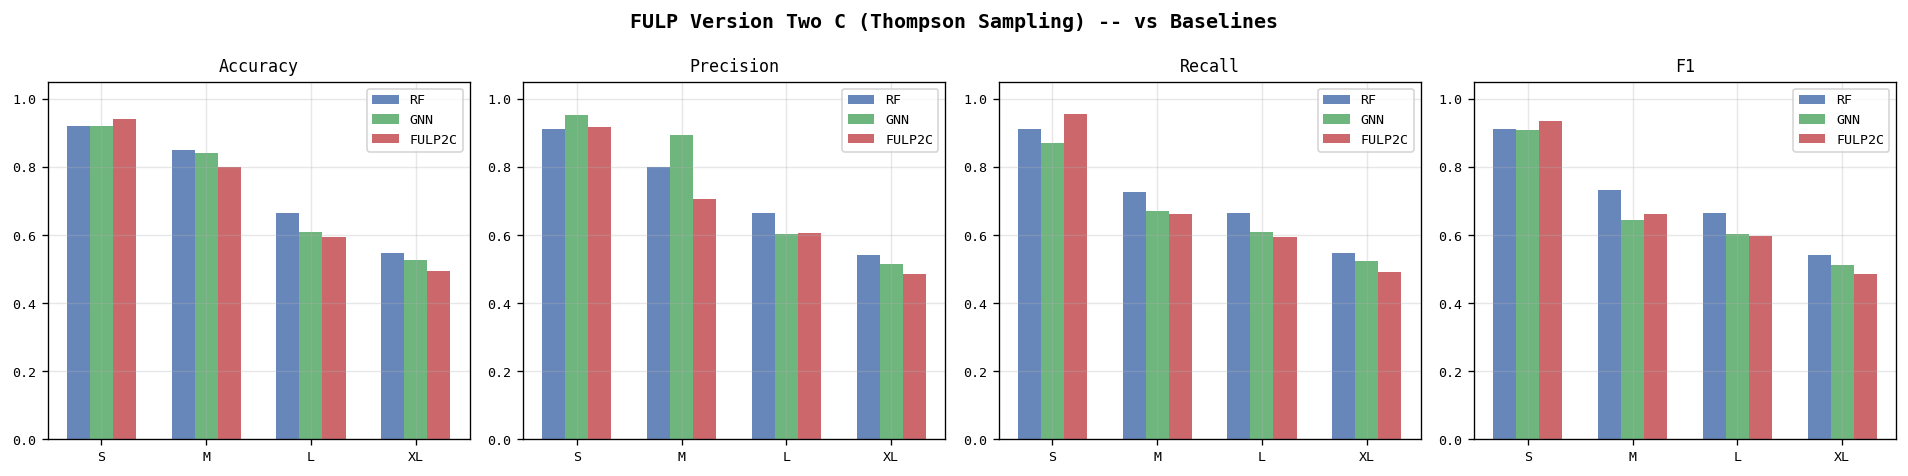

In [152]:
# ── Cell 13: Accuracy Comparison ────────────────────────────────────────────
x=np.arange(len(tiers)); w=0.22
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('FULP Version Two C (Thompson Sampling) -- vs Baselines',fontweight='bold')
for ax,metric in zip(axes,['accuracy','precision','recall','f1']):
    for i,(model,col) in enumerate([('RF','#4c72b0'),('GNN','#55a868'),('FULP2C','#c44e52')]):
        vals=[RESULTS[t][model.lower()][metric] for t in tiers]
        ax.bar(x+(i-1)*w,vals,w,label=model,color=col,alpha=0.85)
    ax.set_title(metric.capitalize()); ax.set_xticks(x); ax.set_xticklabels(tiers)
    ax.set_ylim(0,1.05); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_accuracy.png'),bbox_inches='tight'); plt.show()


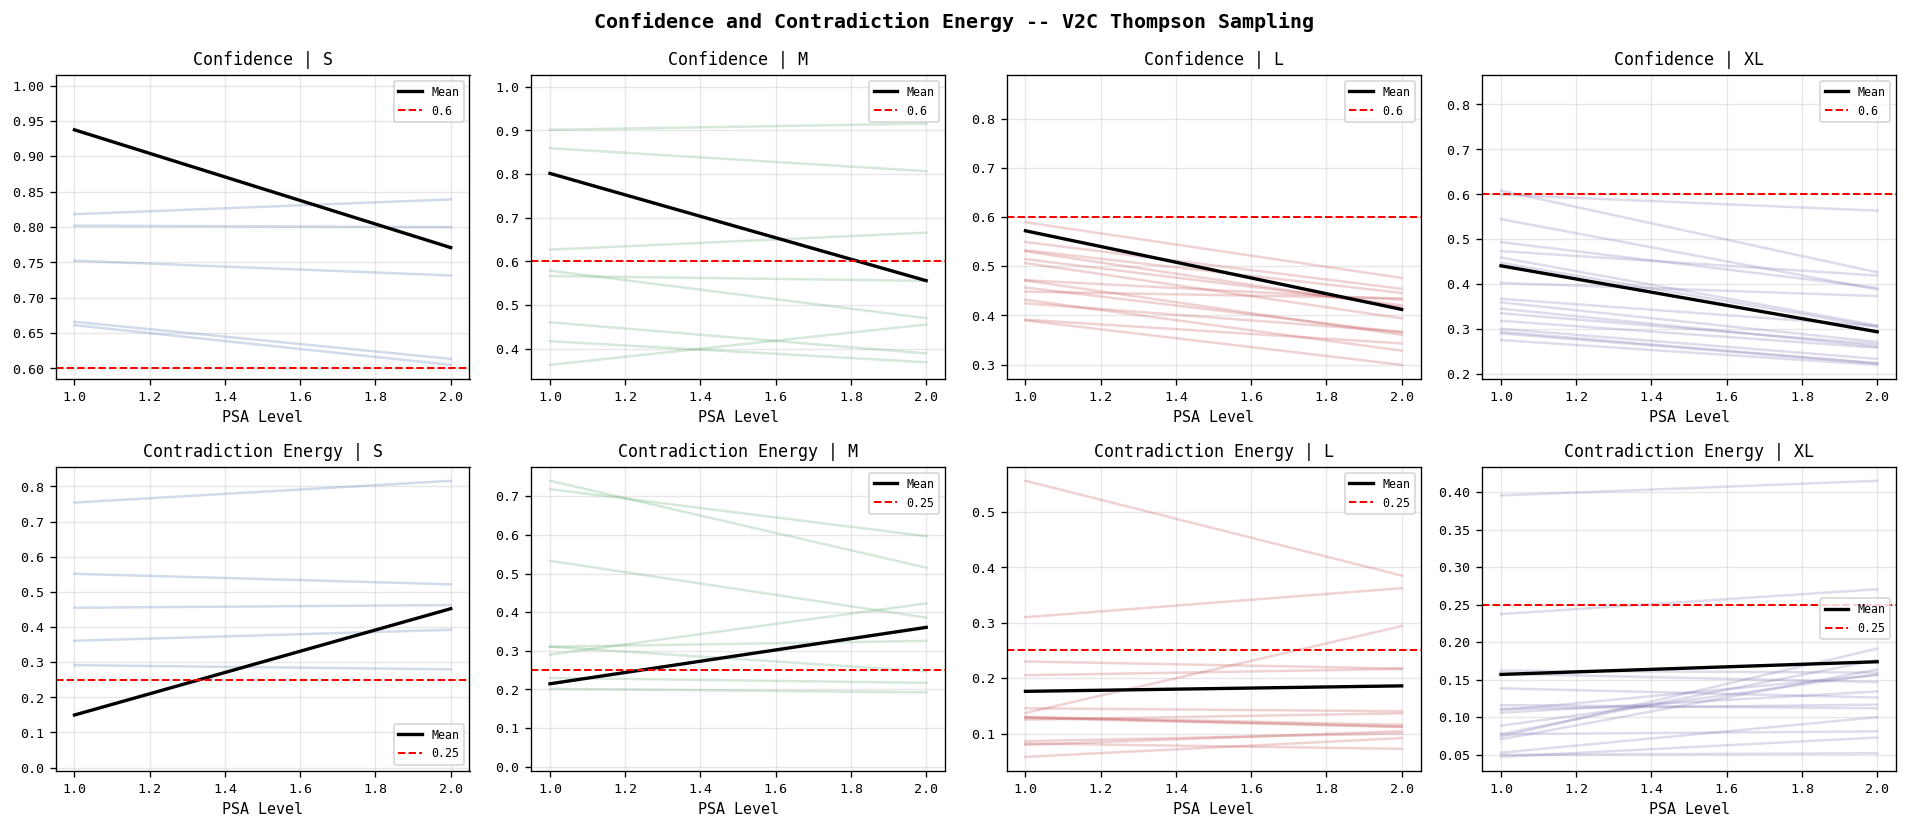

In [153]:
# ── Cell 14: Confidence & Contradiction Evolution ────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,7))
fig.suptitle('Confidence and Contradiction Energy -- V2C Thompson Sampling',fontweight='bold')
for ci,tier in enumerate(tiers):
    all_logs=RESULTS[tier]['all_logs']
    max_len=max((len(lg['confidence_history']) for lg in all_logs if lg['confidence_history']),default=1)
    for log in all_logs[:20]:
        if log['confidence_history']:
            axes[0,ci].plot(range(1,len(log['confidence_history'])+1),
                            log['confidence_history'],alpha=0.25,color=TIER_COLORS[tier])
        if log['contradiction_history']:
            axes[1,ci].plot(range(1,len(log['contradiction_history'])+1),
                            log['contradiction_history'],alpha=0.25,color=TIER_COLORS[tier])
    for ri,(key,thresh,label) in enumerate([
            ('confidence_history',CONF_ACCEPT,'Confidence'),
            ('contradiction_history',CONT_ACCEPT,'Contradiction Energy')]):
        arr=np.full((len(all_logs),max_len),np.nan)
        for i,lg in enumerate(all_logs):
            h=lg[key]; arr[i,:len(h)]=h
        mean_h=np.nanmean(arr,axis=0)
        axes[ri,ci].plot(range(1,max_len+1),mean_h,color='black',lw=2,label='Mean')
        axes[ri,ci].axhline(thresh,color='red',linestyle='--',lw=1.2,label=f'{thresh}')
        axes[ri,ci].set_title(f'{label} | {tier}')
        axes[ri,ci].set_xlabel('PSA Level'); axes[ri,ci].legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_confidence.png'),bbox_inches='tight'); plt.show()


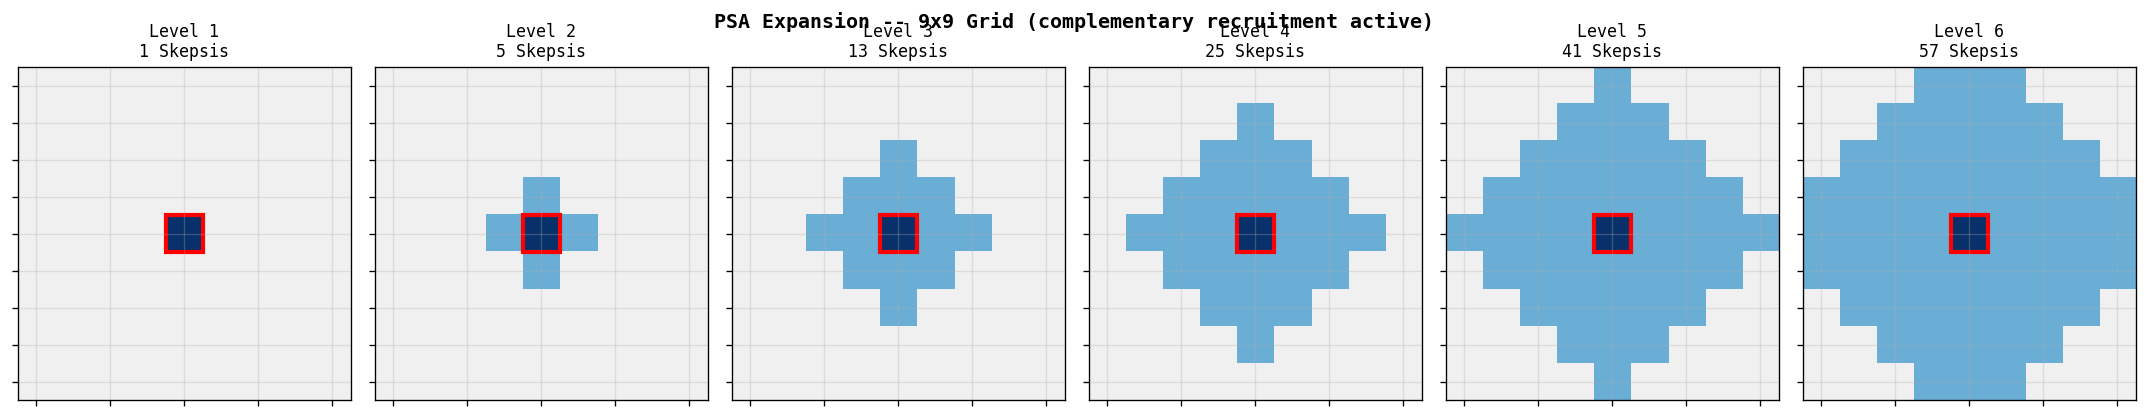

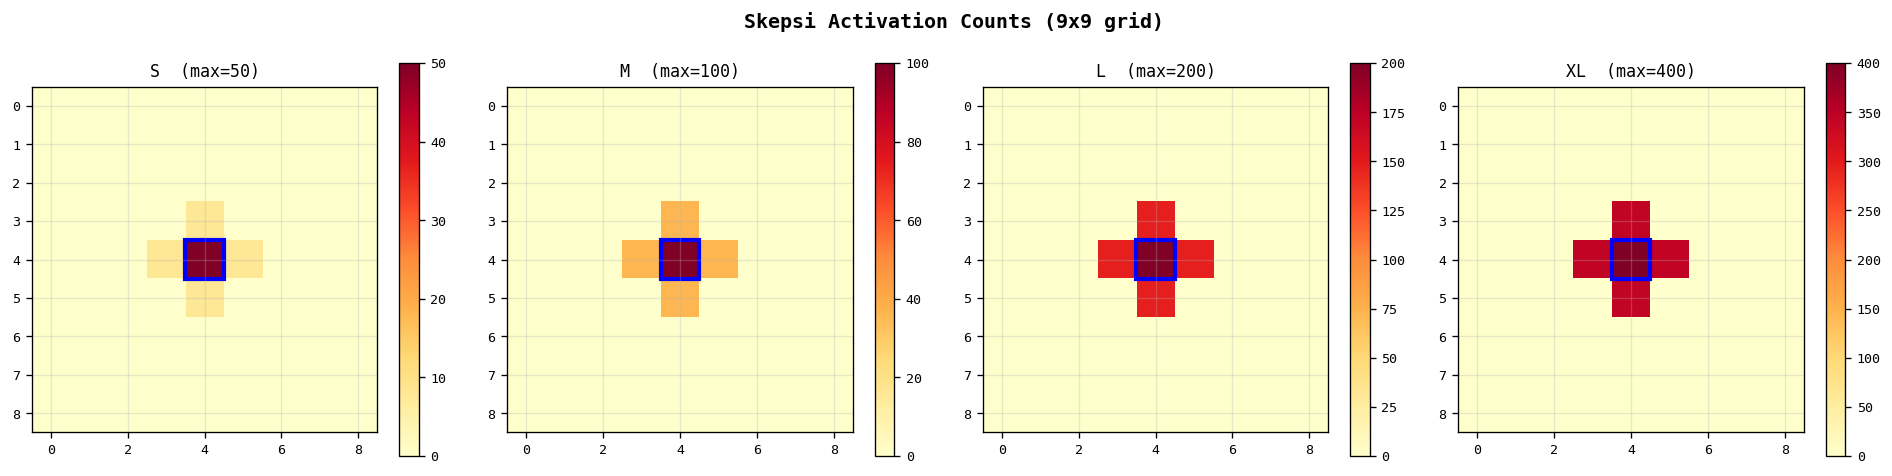

In [154]:
# ── Cell 15: PSA Expansion + Activation Heatmaps ────────────────────────────
enc_s=RESULTS['S']['enc']; H,W=enc_s.grid_h,enc_s.grid_w; cr,cc=enc_s.center
cmap_psa=LinearSegmentedColormap.from_list('psa',['#f0f0f0','#6baed6','#08306b'])

fig,axes=plt.subplots(1,6,figsize=(18,3.5))
fig.suptitle('PSA Expansion -- 9x9 Grid (complementary recruitment active)',fontweight='bold')
for lv_idx,ax in enumerate(axes):
    level=lv_idx+1; active=set(_vn_up_to(cr,cc,level-1,H,W))
    gi=np.zeros((H,W))
    for (r,c) in active: gi[r,c]=1.0
    gi[cr,cc]=2.0
    ax.imshow(gi,cmap=cmap_psa,vmin=0,vmax=2)
    ax.set_title(f'Level {level}\n{len(active)} Skepsis')
    ax.tick_params(labelbottom=False,labelleft=False)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2.5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_psa.png'),bbox_inches='tight'); plt.show()

fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('Skepsi Activation Counts (9x9 grid)',fontweight='bold')
for ax,tier in zip(axes,tiers):
    hm=RESULTS[tier]['heatmap']; enc=RESULTS[tier]['enc']; cr2,cc2=enc.center
    im=ax.imshow(hm,cmap='YlOrRd'); plt.colorbar(im,ax=ax)
    ax.set_title(f'{tier}  (max={hm.max()})')
    ax.add_patch(plt.Rectangle((cc2-0.5,cr2-0.5),1,1,fill=False,edgecolor='blue',lw=2.5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_activation.png'),bbox_inches='tight'); plt.show()


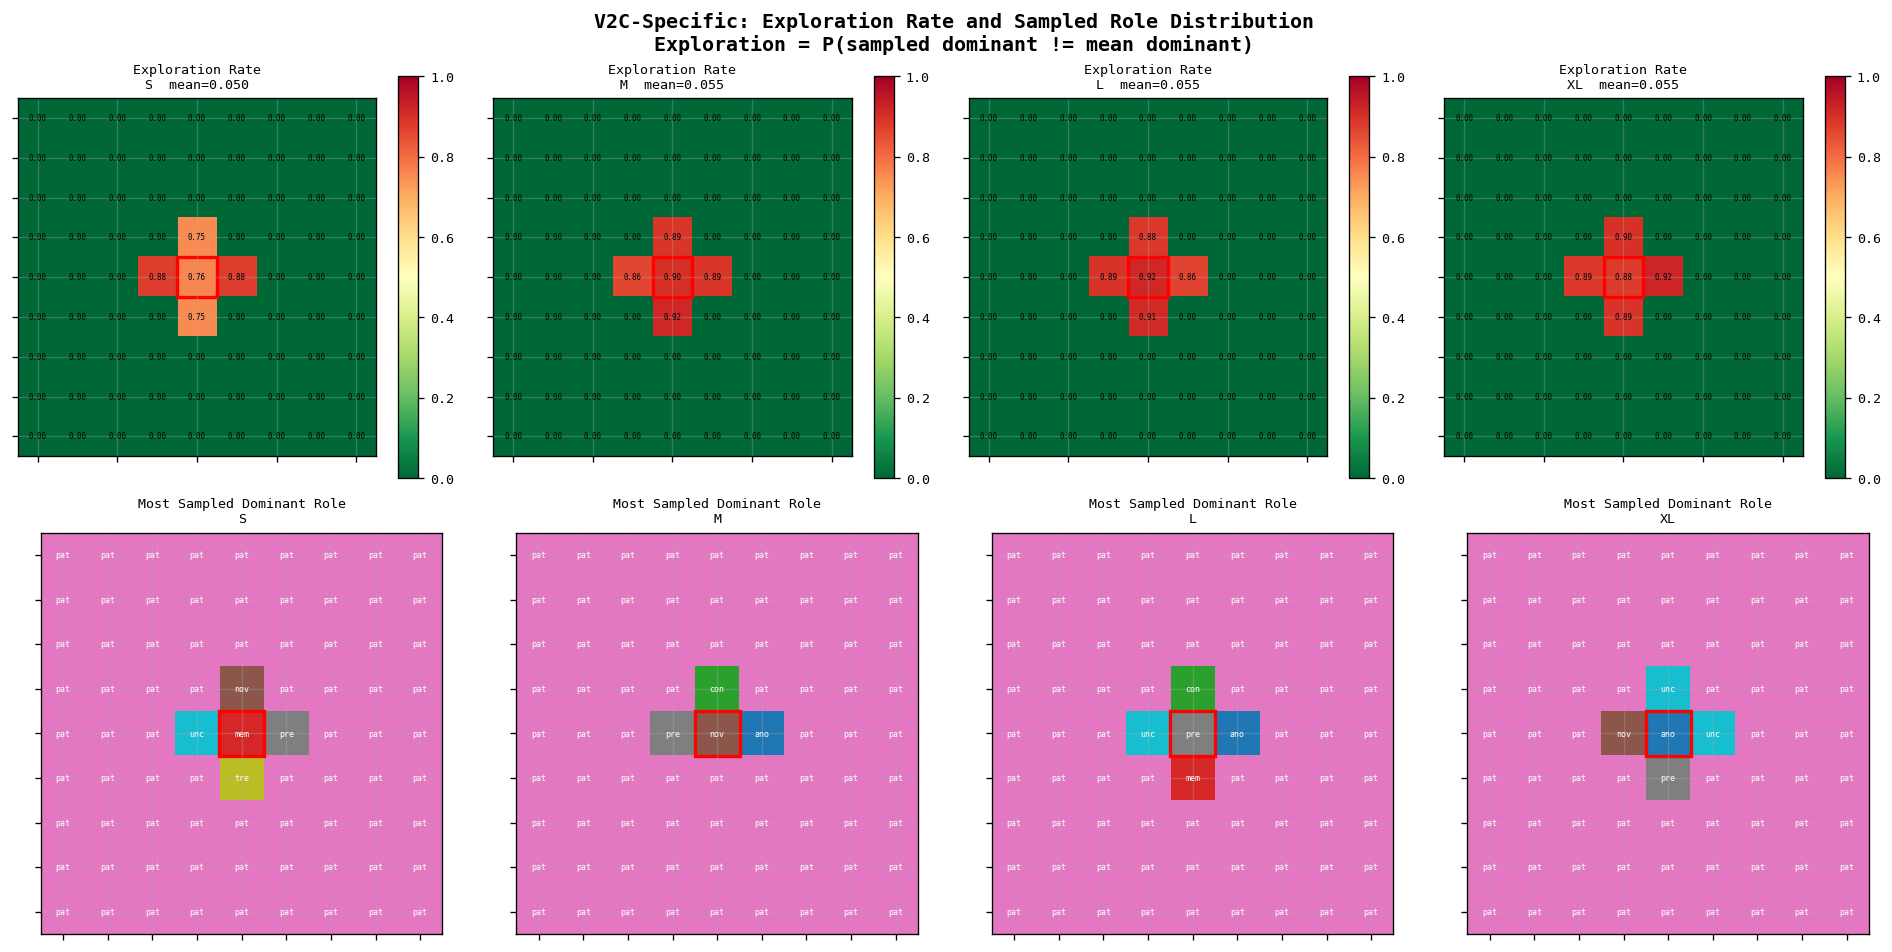


-- V2C Thompson Sampling Sanity Check --
  Tier   Rep mean    Rep obs    Role H     Explore rate    Role diversity   Pct Spec
  ---------------------------------------------------------------------------
  S      0.4995      0.6        0.9944     0.0495          0.1111           1.2%
  M      0.4854      3.0        0.9593     0.0550          0.1111           6.2%
  L      0.4862      9.7        0.9583     0.0551          0.1111           6.2%
  XL     0.4963      4.9        0.9886     0.0552          0.1111           1.2%

  Exploration rate: fraction of inferences where TS sampled a non-dominant role
  Role diversity:   fraction of distinct roles represented in active Symposium

  Expected: exploration rate decreases as Dirichlet concentrates (more data => more exploitation)
  Expected: role diversity higher than V2A because complement recruitment diversifies Symposium


In [155]:
# ── Cell 16: V2C-Specific: Exploration Rate and Sampled Role Distribution ─────
# These two visualisations are unique to V2C because they reflect the Thompson
# Sampling dynamics. They have no equivalent in V2A or V2B.
#
# Exploration rate heatmap:
#   fraction of inferences where sampled dominant role != Dirichlet mean dominant.
#   High = this Skepsi explored frequently (uniform prior or diverse posteriors).
#   Low  = this Skepsi consistently exploited its known best role.
#
# Sampled dominant role grid:
#   Most frequently sampled dominant role per Skepsi across all inferences.
#   Ideally differs from the deterministic dominant grid (V2A would show the same
#   dominant everywhere; V2C should show more variation near boundaries).

fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('V2C-Specific: Exploration Rate and Sampled Role Distribution\n'
             'Exploration = P(sampled dominant != mean dominant)',fontweight='bold')

for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center

    ax=axes[0,ci]; hm=RESULTS[tier]['explore_heatmap']
    im=ax.imshow(hm,cmap='RdYlGn_r',vmin=0,vmax=1)
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Exploration Rate\n{tier}  mean={hm.mean():.3f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    for r in range(hm.shape[0]):
        for c in range(hm.shape[1]):
            ax.text(c,r,f'{hm[r,c]:.2f}',ha='center',va='center',fontsize=4.5,color='black')
    ax.tick_params(labelbottom=False,labelleft=False)

    ax=axes[1,ci]
    dom_grid=RESULTS[tier]['sampled_dom_grid']
    role_to_int={r:i for i,r in enumerate(sorted(ROLE_COLORS))}
    dm=np.array([[role_to_int[dom_grid[r][c]] for c in range(enc.grid_w)]
                  for r in range(enc.grid_h)])
    ax.imshow(dm,cmap=plt.cm.get_cmap('tab10',len(ROLE_COLORS)),vmin=0,vmax=len(ROLE_COLORS)-1)
    ax.set_title(f'Most Sampled Dominant Role\n{tier}',fontsize=8)
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            dom=dom_grid[r][c]
            ax.text(c,r,dom[:3],ha='center',va='center',fontsize=5,color='white')
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_ts_specific.png'),bbox_inches='tight'); plt.show()

# Sanity check
print('\n-- V2C Thompson Sampling Sanity Check --')
print(f'  {"Tier":<5}  {"Rep mean":<10}  {"Rep obs":<9}  '
      f'{"Role H":<9}  {"Explore rate":<14}  {"Role diversity":<15}  {"Pct Spec"}')
print('  '+'-'*75)
for tier in tiers:
    f=RESULTS[tier]['fulp2c']
    print(f'  {tier:<5}  {f["rep_mean"]:<10.4f}  {f["rep_avg_concentration"]:<9.1f}  '
          f'{f["role_entropy_mean"]:<9.4f}  {f["avg_exploration_rate"]:<14.4f}  '
          f'{f["avg_role_diversity"]:<15.4f}  {f["pct_specialised"]*100:.1f}%')
print()
print('  Exploration rate: fraction of inferences where TS sampled a non-dominant role')
print('  Role diversity:   fraction of distinct roles represented in active Symposium')
print()
print('  Expected: exploration rate decreases as Dirichlet concentrates (more data => more exploitation)')
print('  Expected: role diversity higher than V2A because complement recruitment diversifies Symposium')


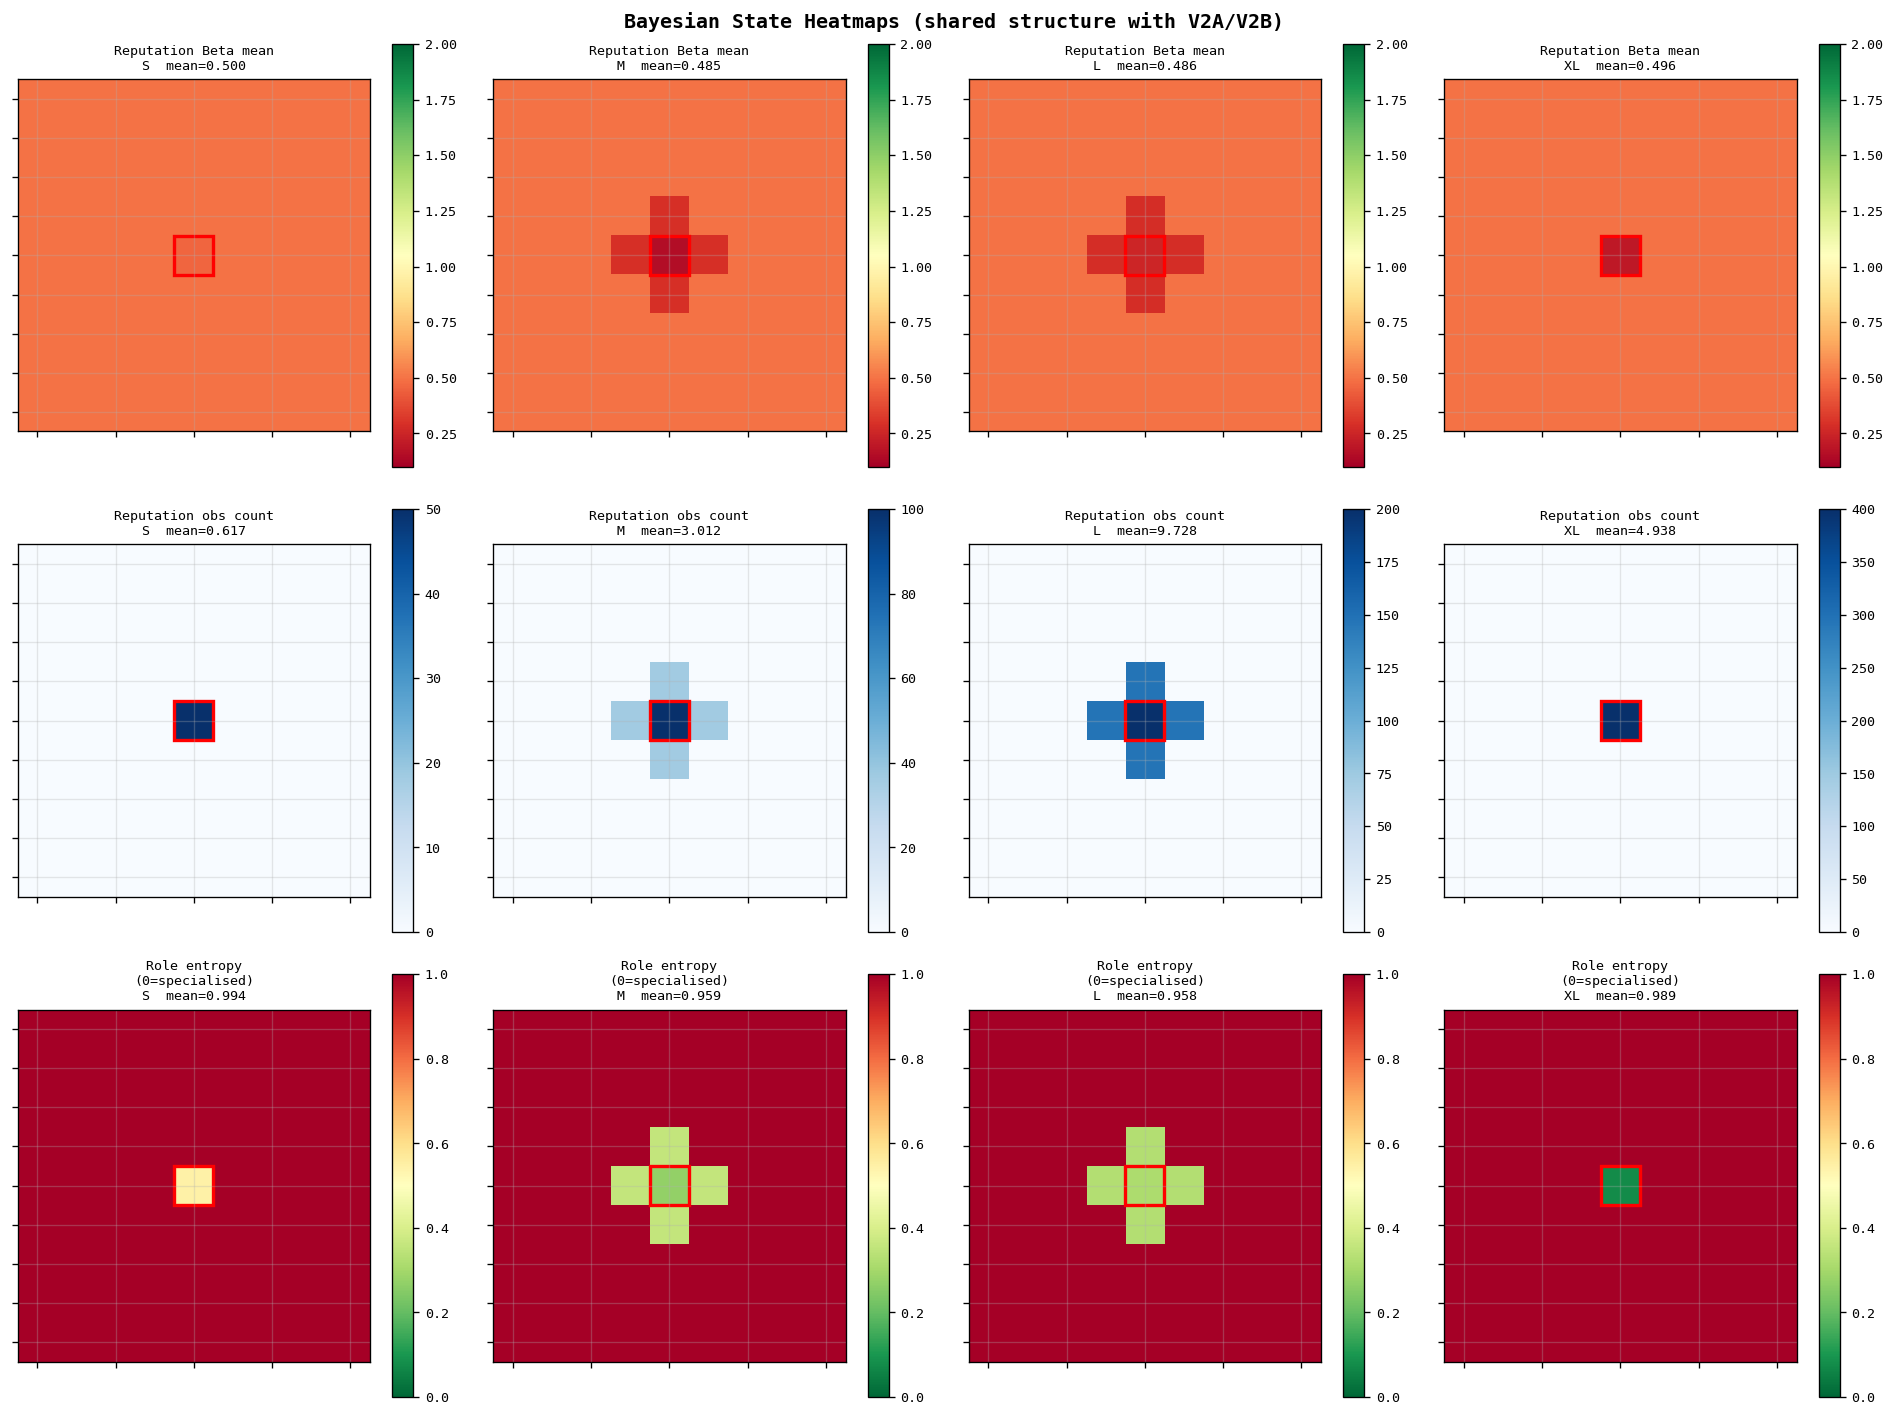

In [156]:
# ── Cell 17: Bayesian Distribution Heatmaps ─────────────────────────────────
fig,axes=plt.subplots(3,4,figsize=(16,12))
fig.suptitle('Bayesian State Heatmaps (shared structure with V2A/V2B)',fontweight='bold')
for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center
    for ri,(key,title,cmap,vmin,vmax) in enumerate([
            ('rep_heatmap',     'Reputation Beta mean',   'RdYlGn',   0.1, 2.0),
            ('rep_conc_heatmap','Reputation obs count',   'Blues',    0,   None),
            ('role_ent_heatmap','Role entropy\n(0=specialised)','RdYlGn_r',0,1.0)]):
        ax=axes[ri,ci]; hm=RESULTS[tier][key]
        im=ax.imshow(hm,cmap=cmap,vmin=vmin,vmax=vmax if vmax else hm.max())
        plt.colorbar(im,ax=ax)
        ax.set_title(f'{title}\n{tier}  mean={hm.mean():.3f}',fontsize=8)
        ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
        ax.tick_params(labelbottom=False,labelleft=False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_bayesian_heatmaps.png'),bbox_inches='tight'); plt.show()


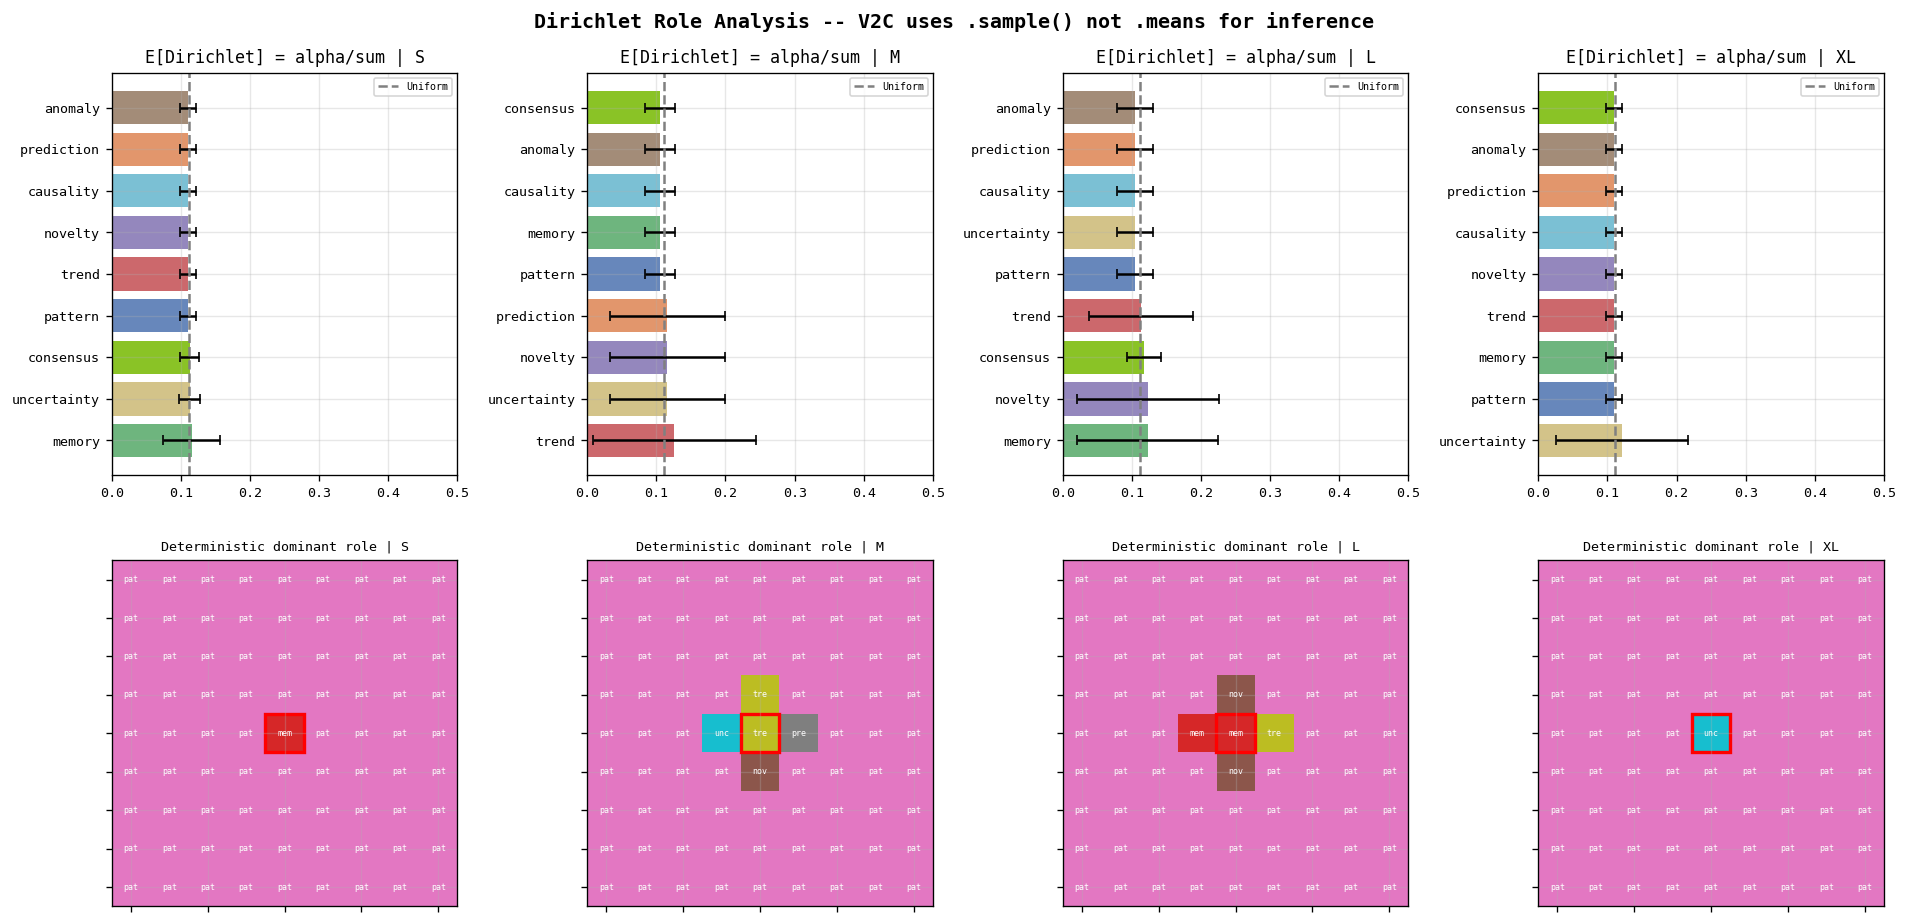

In [157]:
# ── Cell 18: Dirichlet Role Analysis ─────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('Dirichlet Role Analysis -- V2C uses .sample() not .means for inference',
             fontweight='bold')
for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center
    rv_means=enc.role_means_grid(); rv_stds=enc.role_stds_grid()

    ax=axes[0,ci]
    roles_s=sorted(rv_means,key=rv_means.get,reverse=True)
    ax.barh(roles_s,[rv_means[r] for r in roles_s],
            xerr=[rv_stds[r] for r in roles_s],
            color=[ROLE_COLORS[r] for r in roles_s],alpha=0.85,capsize=3)
    ax.axvline(1/len(ALL_ROLES),color='grey',linestyle='--',lw=1.5,label='Uniform')
    ax.set_title(f'E[Dirichlet] = alpha/sum | {tier}'); ax.set_xlim(0,0.5); ax.legend(fontsize=6)

    ax=axes[1,ci]
    dom_grid=enc.dominant_role_grid()
    r2i={r:i for i,r in enumerate(sorted(ROLE_COLORS))}
    dm=np.array([[r2i[dom_grid[r][c]] for c in range(enc.grid_w)] for r in range(enc.grid_h)])
    ax.imshow(dm,cmap=plt.cm.get_cmap('tab10',len(ROLE_COLORS)),vmin=0,vmax=len(ROLE_COLORS)-1)
    ax.set_title(f'Deterministic dominant role | {tier}',fontsize=8)
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            dom=dom_grid[r][c]
            ax.text(c,r,dom[:3],ha='center',va='center',fontsize=5,color='white')
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_roles.png'),bbox_inches='tight'); plt.show()


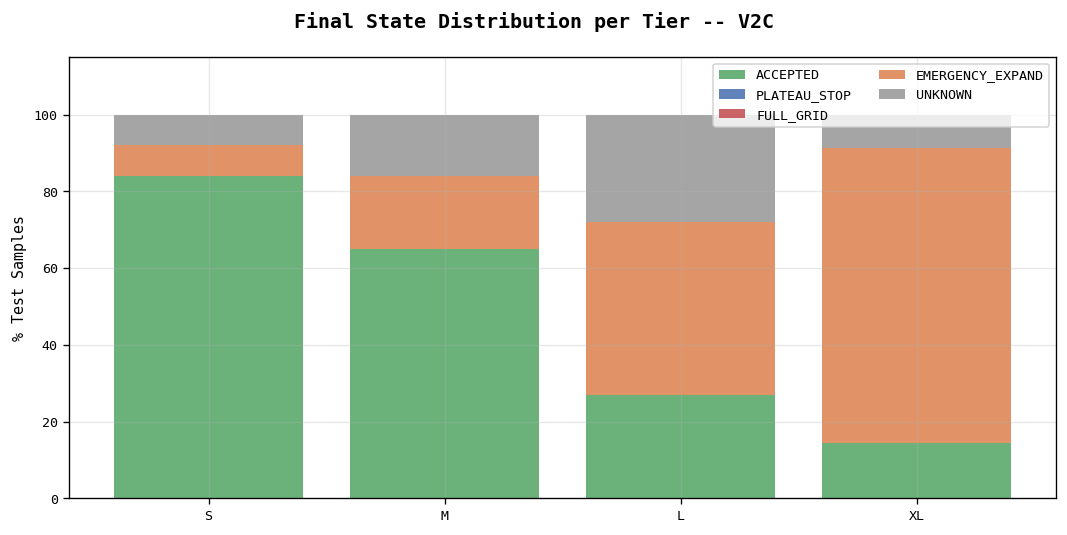

In [158]:
# ── Cell 19: State Transitions ───────────────────────────────────────────────
states=['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND','UNKNOWN']
sc_colors={'ACCEPTED':'#55a868','PLATEAU_STOP':'#4c72b0','FULL_GRID':'#c44e52',
           'EMERGENCY_EXPAND':'#dd8452','UNKNOWN':'#999999'}
fig,ax=plt.subplots(figsize=(9,4.5))
fig.suptitle('Final State Distribution per Tier -- V2C',fontweight='bold')
x=np.arange(len(tiers)); bottoms=np.zeros(len(tiers))
n_samples=[RESULTS[t]['n_test'] for t in tiers]
for state in states:
    vals=[RESULTS[t]['fulp2c'].get('state_counts',{}).get(state,0)/n*100
          for t,n in zip(tiers,n_samples)]
    ax.bar(x,vals,bottom=bottoms,label=state,color=sc_colors[state],alpha=0.88)
    bottoms+=np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(tiers); ax.set_ylabel('% Test Samples')
ax.set_ylim(0,115); ax.legend(loc='upper right',ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_states.png'),bbox_inches='tight'); plt.show()


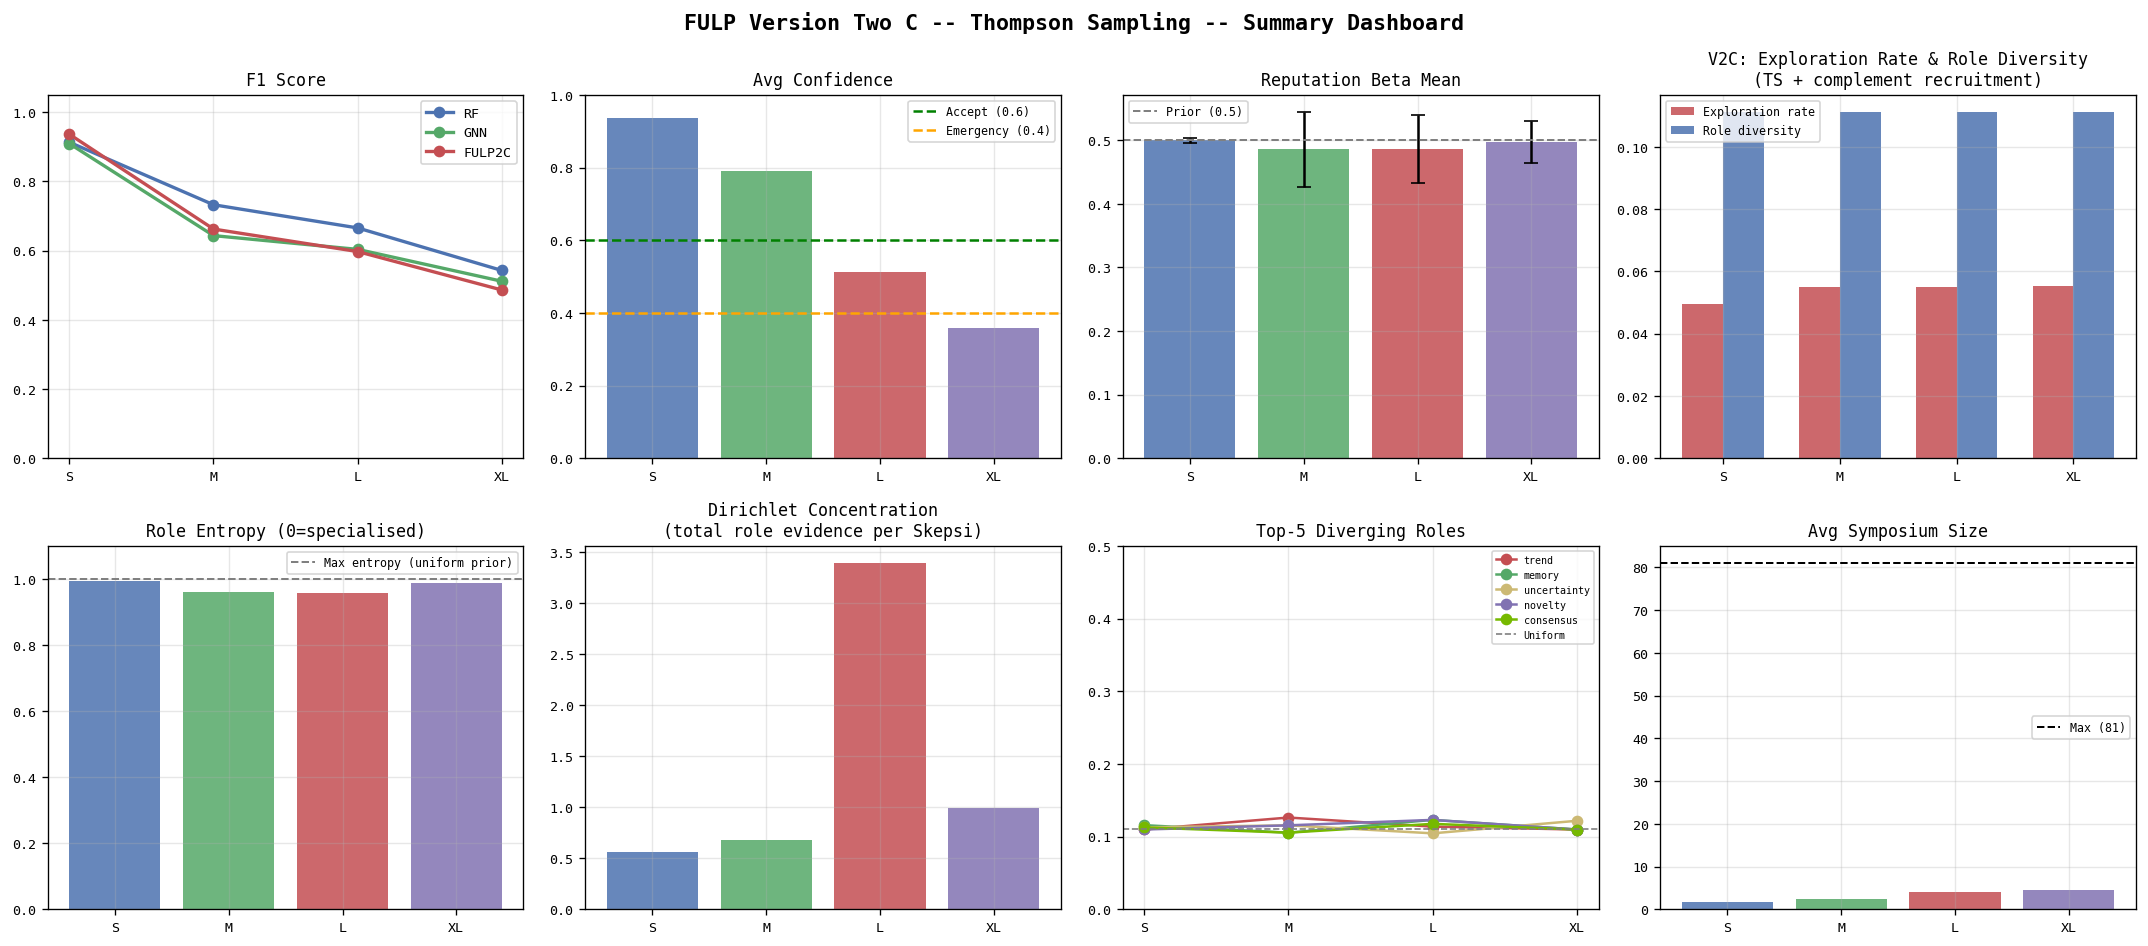

In [159]:
# ── Cell 20: Summary Dashboard ──────────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(18,8))
fig.suptitle('FULP Version Two C -- Thompson Sampling -- Summary Dashboard',
             fontweight='bold',fontsize=13)

ax=axes[0,0]
for model,col in [('RF','#4c72b0'),('GNN','#55a868'),('FULP2C','#c44e52')]:
    vals=[RESULTS[t][model.lower()]['f1'] for t in tiers]
    ax.plot(tiers,vals,'o-',color=col,label=model,lw=2)
ax.set_title('F1 Score'); ax.set_ylim(0,1.05); ax.legend()

ax=axes[0,1]
confs=[RESULTS[t]['fulp2c']['avg_confidence'] for t in tiers]
ax.bar(tiers,confs,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(CONF_ACCEPT,color='green',linestyle='--',lw=1.5,label=f'Accept ({CONF_ACCEPT})')
ax.axhline(CONF_EMERGENCY,color='orange',linestyle='--',lw=1.5,label=f'Emergency ({CONF_EMERGENCY})')
ax.set_title('Avg Confidence'); ax.set_ylim(0,1); ax.legend(fontsize=7)

ax=axes[0,2]
rm=[RESULTS[t]['fulp2c']['rep_mean'] for t in tiers]
rs=[RESULTS[t]['fulp2c']['rep_std']  for t in tiers]
ax.bar(tiers,rm,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.errorbar(tiers,rm,rs,fmt='none',color='black',capsize=4)
ax.axhline(0.5,color='grey',linestyle='--',lw=1.2,label='Prior (0.5)')
ax.set_title('Reputation Beta Mean'); ax.legend(fontsize=7)

ax=axes[0,3]
er=[RESULTS[t]['fulp2c']['avg_exploration_rate'] for t in tiers]
rd=[RESULTS[t]['fulp2c']['avg_role_diversity']   for t in tiers]
x2=np.arange(len(tiers)); w=0.35
ax.bar(x2-w/2,er,w,label='Exploration rate',color='#c44e52',alpha=0.85)
ax.bar(x2+w/2,rd,w,label='Role diversity',  color='#4c72b0',alpha=0.85)
ax.set_title('V2C: Exploration Rate & Role Diversity\n(TS + complement recruitment)')
ax.set_xticks(x2); ax.set_xticklabels(tiers); ax.legend(fontsize=7)

ax=axes[1,0]
entropies=[RESULTS[t]['fulp2c']['role_entropy_mean'] for t in tiers]
ax.bar(tiers,entropies,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(1.0,color='grey',linestyle='--',lw=1.2,label='Max entropy (uniform prior)')
ax.set_title('Role Entropy (0=specialised)'); ax.set_ylim(0,1.1); ax.legend(fontsize=7)

ax=axes[1,1]
concs=[RESULTS[t]['fulp2c']['role_dirichlet_concentration_mean'] for t in tiers]
ax.bar(tiers,concs,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.set_title('Dirichlet Concentration\n(total role evidence per Skepsi)')

ax=axes[1,2]
all_rv={role:[RESULTS[t]['fulp2c']['role_means'][role] for t in tiers] for role in ALL_ROLES}
for role in sorted(ALL_ROLES,key=lambda r:np.std([RESULTS[t]['fulp2c']['role_means'][r] for t in tiers]),reverse=True)[:5]:
    ax.plot(tiers,all_rv[role],'o-',label=role,color=ROLE_COLORS[role],lw=1.5)
ax.axhline(1/len(ALL_ROLES),color='grey',linestyle='--',lw=1,label='Uniform')
ax.set_title('Top-5 Diverging Roles'); ax.set_ylim(0,0.5); ax.legend(fontsize=6)

ax=axes[1,3]
sym=[RESULTS[t]['fulp2c']['avg_symposium_size'] for t in tiers]
ax.bar(tiers,sym,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(GRID_H*GRID_W,color='black',linestyle='--',lw=1.2,label=f'Max ({GRID_H*GRID_W})')
ax.set_title('Avg Symposium Size'); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2c_dashboard.png'),bbox_inches='tight'); plt.show()


In [160]:
# ── Cell 21: Final Summary ───────────────────────────────────────────────────
print('\nFULPs -- Version Two C (Thompson Sampling / Bandit) -- Final Summary')
print('='*76)
fmt='{:<8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>9}'
print(fmt.format('Tier','RF Acc','GNN Acc','V2C Acc','RF F1','GNN F1','V2C F1','Avg Conf'))
print('-'*76)
for tier in tiers:
    r=RESULTS[tier]
    print(fmt.format(tier,
        f'{r["rf"]["accuracy"]:.4f}',f'{r["gnn"]["accuracy"]:.4f}',
        f'{r["fulp2c"]["accuracy"]:.4f}',
        f'{r["rf"]["f1"]:.4f}',f'{r["gnn"]["f1"]:.4f}',
        f'{r["fulp2c"]["f1"]:.4f}',f'{r["fulp2c"]["avg_confidence"]:.4f}'))
print('='*76)

print('\nV2C-Specific Statistics:')
fmt2='{:<8}  {:>10}  {:>9}  {:>10}  {:>14}  {:>14}'
print(fmt2.format('Tier','Rep mean','Dir conc','Explore rt','Role diversity','Pct specialised'))
print('-'*70)
for tier in tiers:
    f=RESULTS[tier]['fulp2c']
    print(fmt2.format(tier,
        f'{f["rep_mean"]:.4f}',f'{f["role_dirichlet_concentration_mean"]:.2f}',
        f'{f["coop_mean"]:.4f}',f'{f["avg_exploration_rate"]:.4f}',
        f'{f["avg_role_diversity"]:.4f}'))
print('='*76)

print(f"""
V2C Reading Guide:

  Exploration rate:
    Starts high when Dirichlet is close to uniform (equal alphas, uncertain about roles).
    Decreases as the posterior concentrates on a few dominant roles.
    A healthy V2C shows high exploration on S (few samples), lower on XL (more samples).
    If exploration rate is near zero on all tiers: Dirichlet concentrated too fast.
    If exploration rate is near 1.0 on all tiers: TS is still exploring, not converging.

  Role diversity (complement recruitment):
    Fraction of distinct roles in the active Symposium at inference time.
    V2C should show higher role diversity than V2A because PSA selects candidates
    with complementary roles preferentially (COMPLEMENT_BIAS={COMPLEMENT_BIAS}).
    Higher diversity = richer collective Symposium = more independent evidence.

  What to compare against V2A:
    V2A and V2C share identical Dirichlet update rules. Role entropy and
    concentration should be similar. The difference lies in whether the system
    uses .means (V2A, deterministic) or .sample() (V2C, stochastic) at inference.
    If V2C shows higher role diversity with similar or better accuracy, Thompson
    Sampling is contributing meaningfully beyond deterministic exploitation.

  What to compare against V2B:
    V2B and V2C use the same geometric mean for FULP 6 and the same evidence-weighted
    combination for FULP 7. The difference is FULP 6 message structure (BP vs direct)
    and role selection (means vs sample). avg_belief_divergence from V2B has no
    equivalent here because V2C does not maintain directed inboxes.

Version Two comparison summary so far:
  V2A: Bayesian foundations, deterministic exploitation
  V2B: Factor Graph message passing with exclusion rule (best for information flow)
  V2C: Thompson Sampling exploration + complementary PSA recruitment (best for diversity)
V3: 50-run synthetic benchmark will formally compare all three.
""".format(COMPLEMENT_BIAS=COMPLEMENT_BIAS))



FULPs -- Version Two C (Thompson Sampling / Bandit) -- Final Summary
Tier        RF Acc   GNN Acc   V2C Acc     RF F1    GNN F1    V2C F1   Avg Conf
----------------------------------------------------------------------------
S           0.9200    0.9200    0.9400    0.9130    0.9091    0.9362     0.9360
M           0.8500    0.8400    0.8000    0.7324    0.6433    0.6622     0.7904
L           0.6650    0.6100    0.5950    0.6655    0.6035    0.5972     0.5117
XL          0.5475    0.5275    0.4950    0.5426    0.5114    0.4862     0.3599

V2C-Specific Statistics:
Tier        Rep mean   Dir conc  Explore rt  Role diversity  Pct specialised
----------------------------------------------------------------------
S             0.4995       0.56      0.5025          0.0495          0.1111
M             0.4854       0.68      0.5114          0.0550          0.1111
L             0.4862       3.39      0.5019          0.0551          0.1111
XL            0.4963       0.99      0.4993        